<a href="https://colab.research.google.com/github/cemrekarabay/Nepenthe/blob/main/epi_siu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install numpy pandas scikit-learn scipy h5py shap xgboost

In [ ]:
DATA_PATH = "/content/drive/MyDrive/cemredata/Turkish Epilepsy Dataset"
OUT_PATH = "/content/drive/MyDrive/cemredata/EEG_outputs"

import os
os.makedirs(OUT_PATH, exist_ok=True)
print("DATA_PATH exists:", os.path.exists(DATA_PATH))
print("OUT_PATH:", OUT_PATH)

DATA_PATH exists: True
OUT_PATH: /content/drive/MyDrive/cemredata/EEG_outputs


In [ ]:
import io
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import loadmat
import h5py

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [ ]:
data_files = list(Path(DATA_PATH).rglob("*.mat"))

print("Number of files:", len(data_files))
data_files[:5]

Number of files: 121


[PosixPath('/content/drive/MyDrive/cemredata/Turkish Epilepsy Dataset/epilepsy/1_epilepsy (1).mat'),
 PosixPath('/content/drive/MyDrive/cemredata/Turkish Epilepsy Dataset/epilepsy/1_epilepsy (10).mat'),
 PosixPath('/content/drive/MyDrive/cemredata/Turkish Epilepsy Dataset/epilepsy/1_epilepsy (11).mat'),
 PosixPath('/content/drive/MyDrive/cemredata/Turkish Epilepsy Dataset/epilepsy/1_epilepsy (12).mat'),
 PosixPath('/content/drive/MyDrive/cemredata/Turkish Epilepsy Dataset/epilepsy/1_epilepsy (13).mat')]

In [ ]:
mat = loadmat(data_files[0])
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data', 'label'])


In [ ]:
eeg = mat['data']
print(eeg.shape)

(48, 36)


In [ ]:
print(type(eeg))
print(getattr(eeg, "dtype", None))
print(getattr(eeg, "shape", None))
print(eeg)

<class 'numpy.ndarray'>
object
(48, 36)
[[array([[ 29.38116832],
         [ 22.84806564],
         [ 15.72104454],
         ...,
         [-64.45794287],
         [-66.63564376],
         [-69.01131746]]) array([[190.57587951],
                                 [167.95240412],
                                 [148.22937429],
                                 ...,
                                 [-89.83919756],
                                 [-89.0270728 ],
                                 [-87.86689458]]) array([[186.19692866],
                                                         [179.07088536],
                                                         [171.54895076],
                                                         ...,
                                                         [-79.4461301 ],
                                                         [-82.41531481],
                                                         [-84.59271693]])
  ... array([[138.47368774],
        

In [ ]:
import numpy as np

data = mat["data"]   # (48,36)

n_seg, n_ch = data.shape
print("segments:", n_seg, "channels:", n_ch)

signals = []

for ch in range(n_ch):
    segs = []
    for s in range(n_seg):
        sig = np.asarray(data[s, ch]).reshape(-1)
        segs.append(sig)

    sig_full = np.concatenate(segs)  # 48 segmenti birleştir
    signals.append(sig_full)

eeg = np.vstack(signals)  # (channels, time)

print("EEG shape:", eeg.shape)

segments: 48 channels: 36
EEG shape: (36, 360000)


In [ ]:
print("Any NaN in eeg? ", np.isnan(eeg).any())
print("Any Inf in eeg? ", np.isinf(eeg).any())

Any NaN in eeg?  False
Any Inf in eeg?  False


In [ ]:
stds = np.std(eeg, axis=1)
print("Min std:", stds.min())
bad = np.where(stds == 0)[0]
print("Zero-std channels:", bad, "count:", len(bad))

Min std: 0.0
Zero-std channels: [35] count: 1


In [ ]:
# NaN/Inf varsa 0 yap
eeg_clean = np.nan_to_num(eeg, nan=0.0, posinf=0.0, neginf=0.0)

stds = np.std(eeg_clean, axis=1)
good_idx = np.where(stds > 1e-12)[0]   # sıfıra çok yakınları da çıkar
print("Good channels:", len(good_idx), "/", eeg_clean.shape[0])

eeg2 = eeg_clean[good_idx, :]
print("EEG cleaned shape:", eeg2.shape)

Good channels: 35 / 36
EEG cleaned shape: (35, 360000)


In [ ]:
corr_matrix = np.corrcoef(eeg2)
corr_vals = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]

print("Corr shape:", corr_matrix.shape)
print("Min:", float(np.min(corr_vals)))
print("Max:", float(np.max(corr_vals)))
print("Mean:", float(np.mean(corr_vals)))
print("Any NaN in corr?", np.isnan(corr_matrix).any())

Corr shape: (35, 35)
Min: -0.9999999999999982
Max: 0.9998953222004054
Mean: 0.0825314039911869
Any NaN in corr? False


In [ ]:
# eeg oluşturduktan sonra:
eeg_clean = np.nan_to_num(eeg, nan=0.0, posinf=0.0, neginf=0.0)
stds = np.std(eeg_clean, axis=1)
good_idx_ref = np.where(stds > 1e-12)[0]
print("Reference good channels:", good_idx_ref, "count:", len(good_idx_ref))

Reference good channels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34] count: 35


In [ ]:
from pathlib import Path
from scipy.io import loadmat
import numpy as np

files = list(Path(DATA_PATH).rglob("*.mat"))
print("Total files:", len(files))

def build_eeg_from_mat(mat):
    data = mat["data"]  # (48,36) object
    n_seg, n_ch = data.shape
    signals = []
    for ch in range(n_ch):
        segs = [np.asarray(data[s, ch]).reshape(-1) for s in range(n_seg)]
        signals.append(np.concatenate(segs))
    eeg = np.vstack(signals)  # (ch, time)
    eeg = np.nan_to_num(eeg, nan=0.0, posinf=0.0, neginf=0.0)
    return eeg

# --- reference mask (ilk dosyadan) ---
mat0 = loadmat(files[0])
eeg0 = build_eeg_from_mat(mat0)
std0 = np.std(eeg0, axis=1)
good_idx_ref = np.where(std0 > 1e-12)[0]
print("Ref good channels count:", len(good_idx_ref), "removed:", set(range(eeg0.shape[0]))-set(good_idx_ref))

def extract_features(mat, good_idx):
    eeg = build_eeg_from_mat(mat)[good_idx, :]
    corr = np.corrcoef(eeg)
    vals = corr[np.triu_indices_from(corr, k=1)]
    return vals

X_list, y_list = [], []

for fp in files:
    mat = loadmat(fp)
    feats = extract_features(mat, good_idx_ref)
    X_list.append(feats)

    if "label" in mat:
        y_list.append(int(mat["label"].flatten()[0]))
    else:
        y_list.append(1 if "epilepsy" in str(fp).lower() else 0)

X = np.vstack(X_list)
y = np.array(y_list)

print("X:", X.shape, "y:", y.shape)
print("classes:", np.unique(y, return_counts=True))

Total files: 121
Ref good channels count: 35 removed: {35}


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


X: (121, 595) y: (121,)
classes: (array([1, 2]), array([50, 71]))


In [ ]:
import numpy as np
y01 = (y == 2).astype(int)   # 2 -> 1 (epilepsi gibi), 1 -> 0
print("classes y01:", np.unique(y01, return_counts=True))

classes y01: (array([0, 1]), array([50, 71]))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y01, test_size=0.2, random_state=42, stratify=y01
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [ ]:
import numpy as np

X_train_s = np.nan_to_num(X_train_s, nan=0.0, posinf=0.0, neginf=0.0)
X_test_s  = np.nan_to_num(X_test_s,  nan=0.0, posinf=0.0, neginf=0.0)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

print("PCA components:", X_train_p.shape[1])
print("Explained variance sum:", pca.explained_variance_ratio_.sum())

PCA components: 49
Explained variance sum: 0.9504698488097967


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"
)
rf.fit(X_train_p, y_train)

pred = rf.predict(X_test_p)
proba = rf.predict_proba(X_test_p)[:, 1]

print("RF ACC:", accuracy_score(y_test, pred))
print("RF F1 :", f1_score(y_test, pred))
print("RF AUC:", roc_auc_score(y_test, proba))

RF ACC: 0.8
RF F1 : 0.8571428571428571
RF AUC: 0.8833333333333333


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train_p, y_train)

pred = dt.predict(X_test_p)
proba = dt.predict_proba(X_test_p)[:, 1]

print("DT ACC:", accuracy_score(y_test, pred))
print("DT F1 :", f1_score(y_test, pred))
print("DT AUC:", roc_auc_score(y_test, proba))

DT ACC: 0.8
DT F1 : 0.8484848484848485
DT AUC: 0.7666666666666666


In [ ]:
!pip -q install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_p, y_train)

pred = xgb.predict(X_test_p)
proba = xgb.predict_proba(X_test_p)[:, 1]

print("XGB ACC:", accuracy_score(y_test, pred))
print("XGB F1 :", f1_score(y_test, pred))
print("XGB AUC:", roc_auc_score(y_test, proba))

XGB ACC: 0.84
XGB F1 : 0.8823529411764706
XGB AUC: 0.94


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf2 = RandomForestClassifier(
    n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"
)
rf2.fit(X_train_s, y_train)

imp = rf2.feature_importances_
top_idx = np.argsort(imp)[::-1][:20]

print("Top 20 feature index:", top_idx)
print("Top 20 importance   :", imp[top_idx])

Top 20 feature index: [541 518 132 182 535 478 512 225 355 491 418 435 189 566 212 545 206 554
 239 186]
Top 20 importance   : [0.03412401 0.02494422 0.01787856 0.01765253 0.01637886 0.01329106
 0.01104521 0.01073198 0.01005775 0.00922131 0.00921899 0.00891625
 0.0085203  0.00827543 0.00787073 0.00729034 0.006614   0.00622911
 0.00600837 0.00582809]


In [ ]:
import numpy as np

n_ch_used = len(good_idx_ref)
ch_names = [f"Ch{idx+1:02d}" for idx in range(n_ch_used)]
print("n_ch_used:", n_ch_used, "example:", ch_names[:5])

n_ch_used: 35 example: ['Ch01', 'Ch02', 'Ch03', 'Ch04', 'Ch05']


In [ ]:
import numpy as np
from scipy.io import loadmat

def corr_matrix_from_file(fp, good_idx):
    mat = loadmat(fp)
    eeg = build_eeg_from_mat(mat)[good_idx, :]   # (35, time)
    C = np.corrcoef(eeg)
    # NaN/Inf varsa temizle
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    return C

corrs = []
labels = []

for fp in files:
    C = corr_matrix_from_file(fp, good_idx_ref)
    corrs.append(C)

    # label 1/2
    mat = loadmat(fp)
    if "label" in mat:
        labels.append(int(mat["label"].flatten()[0]))
    else:
        labels.append(2 if "epilepsy" in str(fp).lower() else 1)

corrs = np.stack(corrs)              # (N, 35, 35)
labels = np.array(labels)            # (N,)
print("corrs:", corrs.shape, "labels:", labels.shape, "classes:", np.unique(labels, return_counts=True))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


corrs: (121, 35, 35) labels: (121,) classes: (array([1, 2]), array([50, 71]))


In [ ]:
import numpy as np

C_normal = corrs[labels == 1].mean(axis=0)
C_epi    = corrs[labels == 2].mean(axis=0)

print("C_normal shape:", C_normal.shape)
print("C_epi shape   :", C_epi.shape)

C_normal shape: (35, 35)
C_epi shape   : (35, 35)


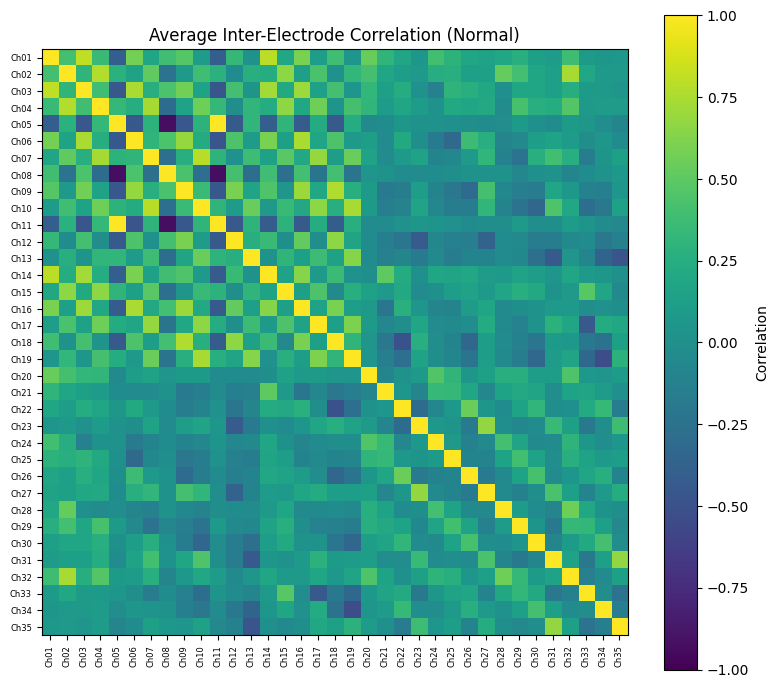

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 7))
plt.imshow(C_normal, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Average Inter-Electrode Correlation (Normal)")
plt.xticks(range(len(ch_names)), ch_names, rotation=90, fontsize=6)
plt.yticks(range(len(ch_names)), ch_names, fontsize=6)
plt.tight_layout()
plt.show()

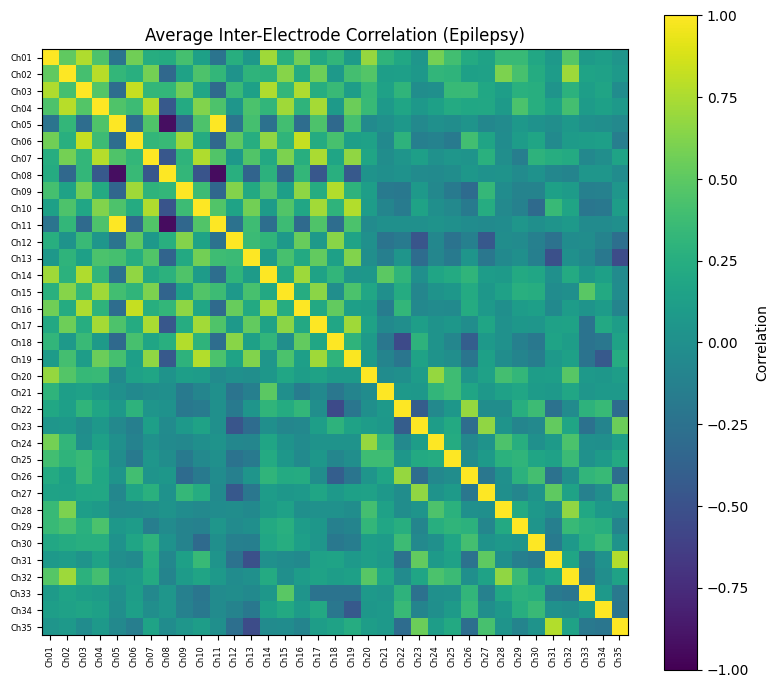

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 7))
plt.imshow(C_epi, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Average Inter-Electrode Correlation (Epilepsy)")
plt.xticks(range(len(ch_names)), ch_names, rotation=90, fontsize=6)
plt.yticks(range(len(ch_names)), ch_names, fontsize=6)
plt.tight_layout()
plt.show()

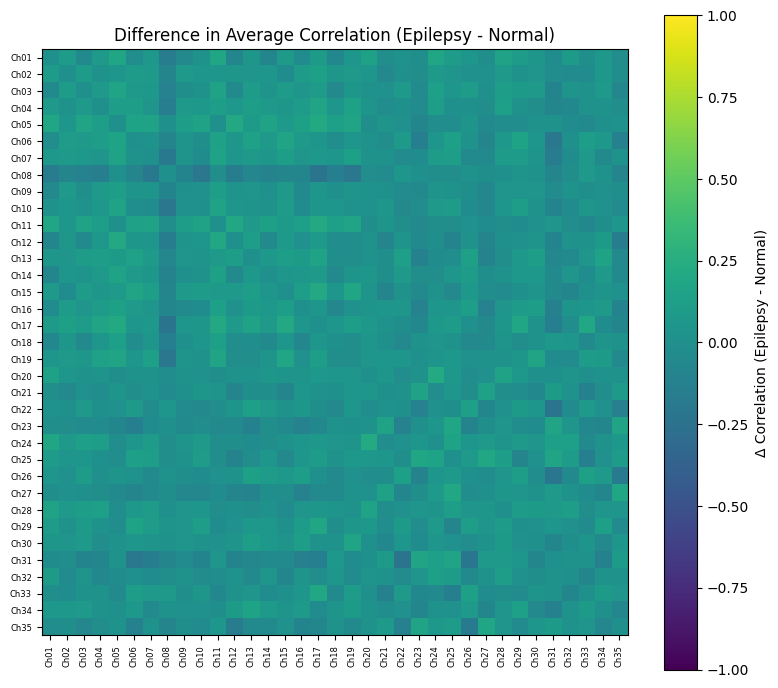

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

C_diff = C_epi - C_normal

plt.figure(figsize=(8, 7))
plt.imshow(C_diff, vmin=-1, vmax=1)
plt.colorbar(label="Δ Correlation (Epilepsy - Normal)")
plt.title("Difference in Average Correlation (Epilepsy - Normal)")
plt.xticks(range(len(ch_names)), ch_names, rotation=90, fontsize=6)
plt.yticks(range(len(ch_names)), ch_names, fontsize=6)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def top_pairs_from_corr(C, ch_names, top_k=10):
    iu = np.triu_indices_from(C, k=1)
    vals = C[iu]
    idx_sorted = np.argsort(np.abs(vals))[::-1]  # mutlak değere göre büyükten küçüğe

    pairs = []
    for k in range(top_k):
        i = iu[0][idx_sorted[k]]
        j = iu[1][idx_sorted[k]]
        pairs.append((ch_names[i], ch_names[j], float(C[i, j]), float(abs(C[i, j]))))
    return pairs

topN_normal = top_pairs_from_corr(C_normal, ch_names, top_k=10)
topN_epi    = top_pairs_from_corr(C_epi, ch_names, top_k=10)

print("Top-10 Normal (by |corr|):")
for p in topN_normal:
    print(p)

print("\nTop-10 Epilepsy (by |corr|):")
for p in topN_epi:
    print(p)

Top-10 Normal (by |corr|):
('Ch05', 'Ch11', 0.9923452881213082, 0.9923452881213082)
('Ch05', 'Ch08', -0.9274739406961295, 0.9274739406961295)
('Ch08', 'Ch11', -0.9240591827474218, 0.9240591827474218)
('Ch01', 'Ch03', 0.81131391312448, 0.81131391312448)
('Ch01', 'Ch14', 0.7912635483099502, 0.7912635483099502)
('Ch07', 'Ch10', 0.78457514772631, 0.78457514772631)
('Ch02', 'Ch04', 0.7688448239066068, 0.7688448239066068)
('Ch09', 'Ch18', 0.762944618867835, 0.762944618867835)
('Ch06', 'Ch16', 0.7453540371531987, 0.7453540371531987)
('Ch03', 'Ch06', 0.742689696452084, 0.742689696452084)

Top-10 Epilepsy (by |corr|):
('Ch05', 'Ch11', 0.994421307556917, 0.994421307556917)
('Ch08', 'Ch11', -0.9369704595675906, 0.9369704595675906)
('Ch05', 'Ch08', -0.9265828360378637, 0.9265828360378637)
('Ch03', 'Ch06', 0.8244962441977746, 0.8244962441977746)
('Ch06', 'Ch16', 0.8213246223753015, 0.8213246223753015)
('Ch02', 'Ch04', 0.7851470656061967, 0.7851470656061967)
('Ch04', 'Ch07', 0.7781159953596912, 0.77

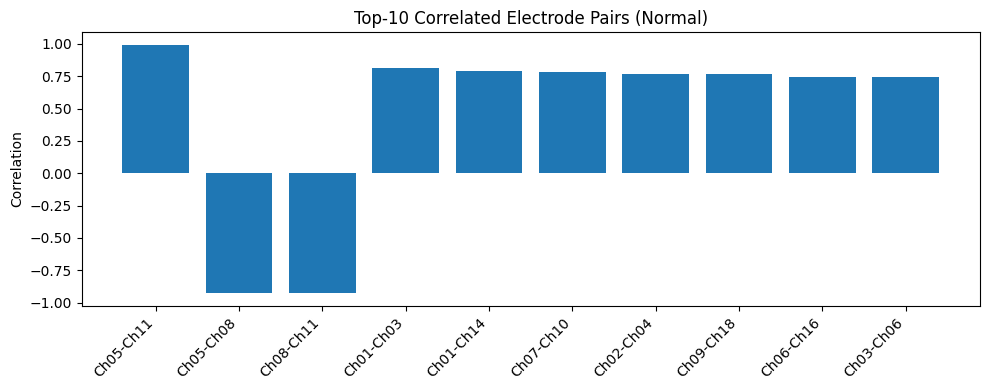

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels_n = [f"{a}-{b}" for a,b,_,_ in topN_normal]
values_n = [c for _,_,c,_ in topN_normal]

plt.figure(figsize=(10, 4))
plt.bar(labels_n, values_n)
plt.title("Top-10 Correlated Electrode Pairs (Normal)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

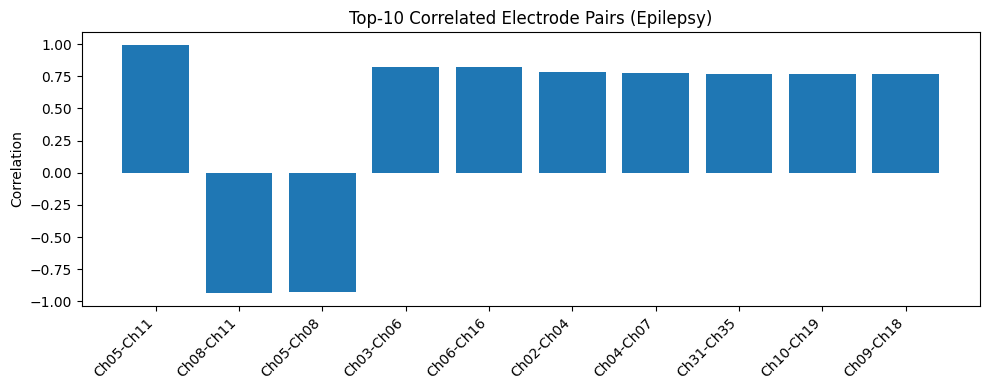

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels_e = [f"{a}-{b}" for a,b,_,_ in topN_epi]
values_e = [c for _,_,c,_ in topN_epi]

plt.figure(figsize=(10, 4))
plt.bar(labels_e, values_e)
plt.title("Top-10 Correlated Electrode Pairs (Epilepsy)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

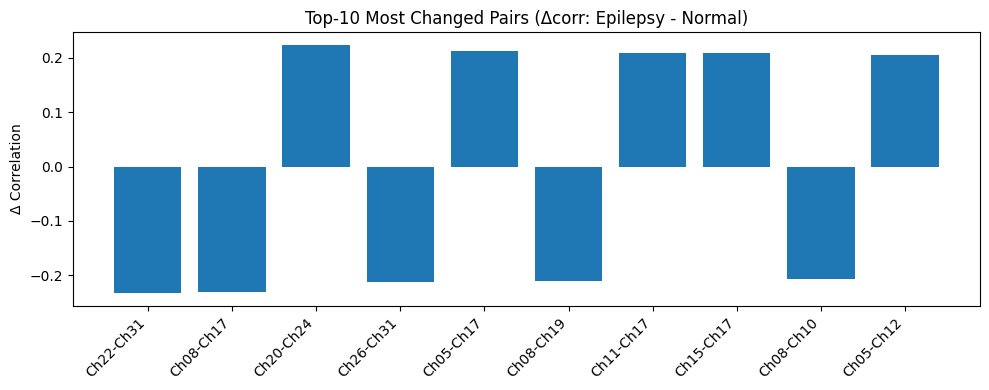

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

iu = np.triu_indices_from(C_diff, k=1)
vals = C_diff[iu]
idx_sorted = np.argsort(np.abs(vals))[::-1][:10]

pairs = []
for idx in idx_sorted:
    i = iu[0][idx]
    j = iu[1][idx]
    pairs.append((ch_names[i], ch_names[j], float(C_diff[i,j])))

labels_d = [f"{a}-{b}" for a,b,_ in pairs]
values_d = [v for _,_,v in pairs]

plt.figure(figsize=(10, 4))
plt.bar(labels_d, values_d)
plt.title("Top-10 Most Changed Pairs (Δcorr: Epilepsy - Normal)")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Δ Correlation")
plt.tight_layout()
plt.show()

Confusion Matrix:
 [[ 5  5]
 [ 0 15]]

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.5000    0.6667        10
           1     0.7500    1.0000    0.8571        15

    accuracy                         0.8000        25
   macro avg     0.8750    0.7500    0.7619        25
weighted avg     0.8500    0.8000    0.7810        25



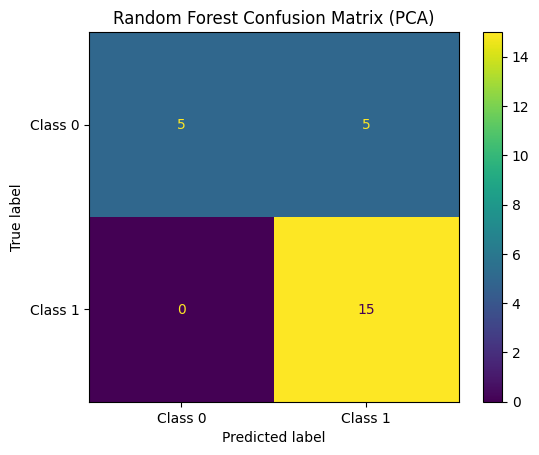

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y01, test_size=0.2, random_state=42, stratify=y01
)

# scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# NaN/Inf temizliği
X_train_s = np.nan_to_num(X_train_s, nan=0.0, posinf=0.0, neginf=0.0)
X_test_s  = np.nan_to_num(X_test_s,  nan=0.0, posinf=0.0, neginf=0.0)

# PCA
pca = PCA(n_components=0.95, random_state=42)
X_train_p = pca.fit_transform(X_train_s)
X_test_p  = pca.transform(X_test_s)

# RF
rf = RandomForestClassifier(
    n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"
)
rf.fit(X_train_p, y_train)

pred = rf.predict(X_test_p)

cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, pred, digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix (PCA)")
plt.show()

In [ ]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

In [ ]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

xgb_pipe = Pipeline([
    ("nanfix", FunctionTransformer(lambda X: np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0))),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("xgb", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_xgb = cross_validate(
    xgb_pipe, X, y01, cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

print("XGB 5-Fold CV Results")
print("ACC mean±std:", float(scores_xgb["test_accuracy"].mean()), "±", float(scores_xgb["test_accuracy"].std()))
print("F1  mean±std:", float(scores_xgb["test_f1"].mean()),       "±", float(scores_xgb["test_f1"].std()))
print("AUC mean±std:", float(scores_xgb["test_roc_auc"].mean()),   "±", float(scores_xgb["test_roc_auc"].std()))

XGB 5-Fold CV Results
ACC mean±std: 0.7856666666666666 ± 0.058495963773390204
F1  mean±std: 0.8196059113300492 ± 0.050163555931201614
AUC mean±std: 0.8808571428571428 ± 0.04036163059750928


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

importance = rf2.feature_importances_

idx = np.argsort(importance)[::-1]

print("Top 20 Features:")
for i in range(20):
    print(f"Feature {idx[i]} importance: {importance[idx[i]]:.6f}")

Top 20 Features:
Feature 541 importance: 0.034124
Feature 518 importance: 0.024944
Feature 132 importance: 0.017879
Feature 182 importance: 0.017653
Feature 535 importance: 0.016379
Feature 478 importance: 0.013291
Feature 512 importance: 0.011045
Feature 225 importance: 0.010732
Feature 355 importance: 0.010058
Feature 491 importance: 0.009221
Feature 418 importance: 0.009219
Feature 435 importance: 0.008916
Feature 189 importance: 0.008520
Feature 566 importance: 0.008275
Feature 212 importance: 0.007871
Feature 545 importance: 0.007290
Feature 206 importance: 0.006614
Feature 554 importance: 0.006229
Feature 239 importance: 0.006008
Feature 186 importance: 0.005828


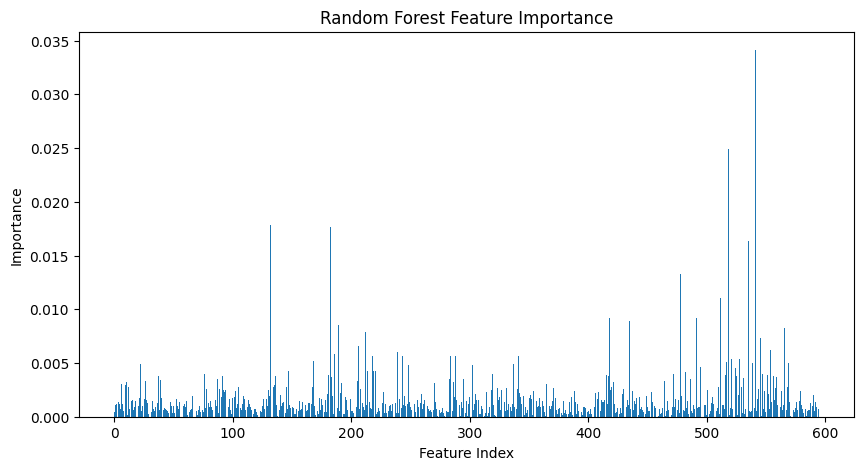

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

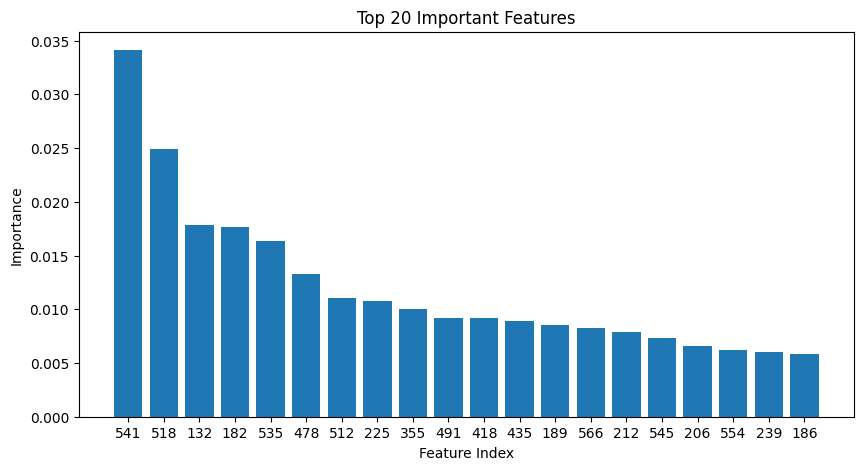

In [ ]:
top_n = 20

top_idx = np.argsort(importance)[::-1][:top_n]

plt.figure(figsize=(10,5))
plt.bar(range(top_n), importance[top_idx])
plt.xticks(range(top_n), top_idx)
plt.title("Top 20 Important Features")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [ ]:
import numpy as np
print("X_train_s:", X_train_s.shape)
print("X_test_s :", X_test_s.shape)

X_train_s: (96, 595)
X_test_s : (25, 595)


In [ ]:
import shap
import numpy as np

explainer = shap.TreeExplainer(rf2)

shap_values = explainer.shap_values(X_train_s)

# shap_values normalize: hedef -> sv = (n_samples, n_features)
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1
else:
    sv = shap_values
    if sv.ndim == 3:
        sv = sv[1]       # class 1

print("Raw sv shape:", sv.shape)

Raw sv shape: (595, 2)


In [ ]:
import shap
import numpy as np

# train verisi
explainer2 = shap.Explainer(rf2, X_train_s)

sv_obj = explainer2(X_train_s)     # explanation object
vals = sv_obj.values               # ndarray

print("sv_obj.values shape:", vals.shape)

# Binary ise (n_samples, n_features, 2) gelebilir -> class 1 al
if vals.ndim == 3:
    vals = vals[:, :, 1]

sv = vals
print("Final sv shape:", sv.shape)

sv_obj.values shape: (96, 595, 2)
Final sv shape: (96, 595)


In [ ]:
shap_importance = np.abs(sv).mean(axis=0)   # (n_features,)
idx = np.argsort(shap_importance)[::-1]

print("Top 20 SHAP Features:")
for k in range(20):
    fi = int(idx[k])
    print(f"{k+1:02d}) Feature {fi}  SHAP_importance: {float(shap_importance[fi]):.6f}")

Top 20 SHAP Features:
01) Feature 541  SHAP_importance: 0.019040
02) Feature 518  SHAP_importance: 0.014263
03) Feature 132  SHAP_importance: 0.011163
04) Feature 182  SHAP_importance: 0.008760
05) Feature 535  SHAP_importance: 0.008439
06) Feature 478  SHAP_importance: 0.007509
07) Feature 355  SHAP_importance: 0.006647
08) Feature 512  SHAP_importance: 0.006573
09) Feature 418  SHAP_importance: 0.005698
10) Feature 435  SHAP_importance: 0.005400
11) Feature 491  SHAP_importance: 0.005373
12) Feature 225  SHAP_importance: 0.005026
13) Feature 212  SHAP_importance: 0.004959
14) Feature 566  SHAP_importance: 0.004796
15) Feature 189  SHAP_importance: 0.004685
16) Feature 284  SHAP_importance: 0.004683
17) Feature 545  SHAP_importance: 0.004628
18) Feature 239  SHAP_importance: 0.004351
19) Feature 243  SHAP_importance: 0.004237
20) Feature 186  SHAP_importance: 0.003782


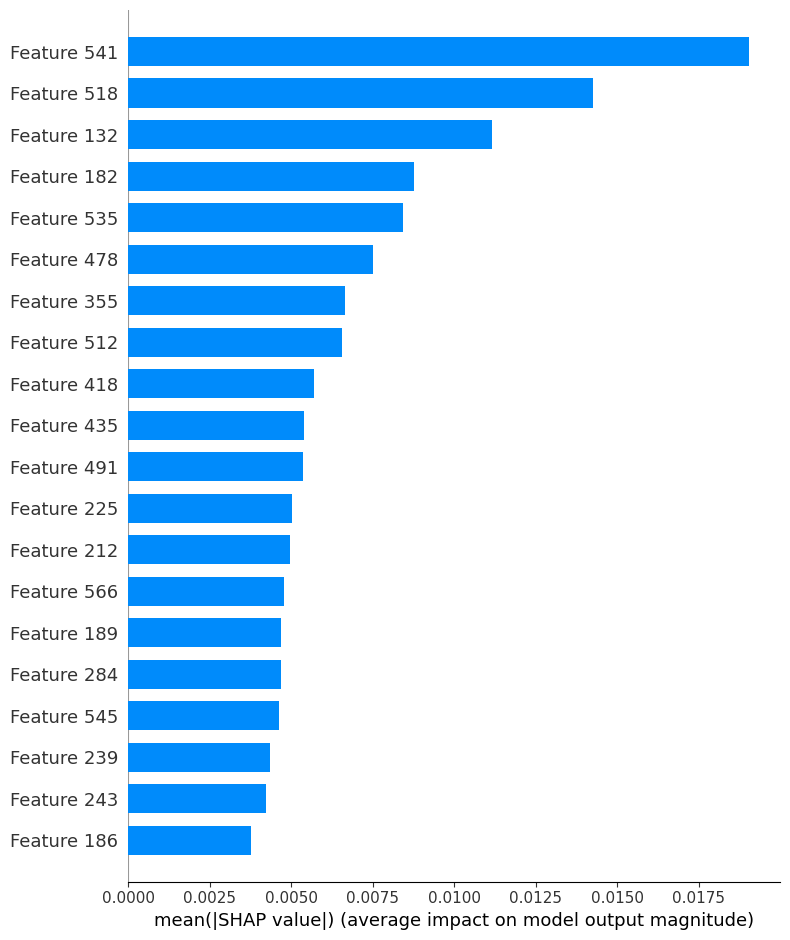

In [ ]:
shap.summary_plot(sv, X_train_s, plot_type="bar", max_display=20)

In [ ]:
import numpy as np

iu = np.triu_indices(n, k=1)

import numpy as np

# final channel count
n = 35
iu = np.triu_indices(n, k=1)

real_ch_names = [
    "FP1A1", "FP2A2", "F3A1", "F4A2", "FZA2",
    "C3A1", "C4A2", "CZA1", "P3A1", "P4A2",
    "PZA2", "O1A1", "O2A2", "F7A1", "F8A1",
    "T3A1", "T4A2", "T5A1", "T6A2",
    "FP1F7", "F7T3", "T3T5", "T5O1",
    "FP1F3", "F3C3", "C3P3", "P3O1",
    "P2P4", "F4C4", "C4P4", "P4O2",
    "FP2F8", "F8T4", "T4T6", "T6O2"
]

assert n == 35, f"Expected 35 channels, got {n}"

ch_names = real_ch_names[:n]

print("Channel mapping:")
for i, ch in enumerate(ch_names, 1):
    print(f"Ch{i:02d} -> {ch}")

def feature_to_pair(f_idx):
    i = int(iu[0][f_idx])
    j = int(iu[1][f_idx])
    return ch_names[i], ch_names[j]

print("Feature 0 ->", feature_to_pair(0))

def feature_to_pair(f_idx):
    i = int(iu[0][f_idx])
    j = int(iu[1][f_idx])
    return ch_names[i], ch_names[j]

print("Feature 0 ->", feature_to_pair(0))

Channel mapping:
Ch01 -> FP1A1
Ch02 -> FP2A2
Ch03 -> F3A1
Ch04 -> F4A2
Ch05 -> FZA2
Ch06 -> C3A1
Ch07 -> C4A2
Ch08 -> CZA1
Ch09 -> P3A1
Ch10 -> P4A2
Ch11 -> PZA2
Ch12 -> O1A1
Ch13 -> O2A2
Ch14 -> F7A1
Ch15 -> F8A1
Ch16 -> T3A1
Ch17 -> T4A2
Ch18 -> T5A1
Ch19 -> T6A2
Ch20 -> FP1F7
Ch21 -> F7T3
Ch22 -> T3T5
Ch23 -> T5O1
Ch24 -> FP1F3
Ch25 -> F3C3
Ch26 -> C3P3
Ch27 -> P3O1
Ch28 -> P2P4
Ch29 -> F4C4
Ch30 -> C4P4
Ch31 -> P4O2
Ch32 -> FP2F8
Ch33 -> F8T4
Ch34 -> T4T6
Ch35 -> T6O2
Feature 0 -> ('FP1A1', 'FP2A2')
Feature 0 -> ('FP1A1', 'FP2A2')


In [ ]:
# ============================================================
# FEATURE INDEX -> REAL ELECTRODE PAIR
# ============================================================

feature_names = [
    f"{feature_to_pair(k)[0]}-{feature_to_pair(k)[1]}"
    for k in range(len(iu[0]))
]

print("n_channels:", n)
print("n_features:", len(feature_names))
print("Feature 0 name:", feature_names[0])
print("Feature 1 name:", feature_names[1])
print("Feature 10 name:", feature_names[10])
print("Feature 541 name:", feature_names[541])

feature_map_df = pd.DataFrame({
    "FeatureIndex": np.arange(len(feature_names)),
    "FeatureName": feature_names
})

display(feature_map_df.head(20))

n_channels: 35
n_features: 595
Feature 0 name: FP1A1-FP2A2
Feature 1 name: FP1A1-F3A1
Feature 10 name: FP1A1-O1A1
Feature 541 name: F3C3-P3O1


,FeatureIndex,FeatureName
0,0,FP1A1-FP2A2
1,1,FP1A1-F3A1
2,2,FP1A1-F4A2
3,3,FP1A1-FZA2
4,4,FP1A1-C3A1
5,5,FP1A1-C4A2
6,6,FP1A1-CZA1
7,7,FP1A1-P3A1
8,8,FP1A1-P4A2
9,9,FP1A1-PZA2


In [ ]:
# ============================================================
# RANDOM FOREST TRAINING
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# X_train_s, X_test_s, y_train, y_test daha önce oluşmuş olmalı
rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf2.fit(X_train_s, y_train)

print("rf2 hazır")
print("Train accuracy:", rf2.score(X_train_s, y_train))
print("Test accuracy :", rf2.score(X_test_s, y_test))

rf2 hazır
Train accuracy: 1.0
Test accuracy : 0.72


In [ ]:
# ============================================================
# SHAP VALUES COMPUTATION
# ============================================================

import shap
import numpy as np

# rf2 ve X_train_s daha önce oluşmuş olmalı
explainer = shap.Explainer(rf2, X_train_s)
sv_obj = explainer(X_train_s)

vals = sv_obj.values

# Eğer 3 boyutlu gelirse binary class için class-1 seç
if vals.ndim == 3:
    vals = vals[:, :, 1]

sv = vals

print("sv shape:", sv.shape)

sv shape: (96, 595)


In [ ]:
import numpy as np

# 1) Kullanılan kanal sayısı
n = len(good_idx_ref)   # örn: 35

# 2) Kanal isimleri

ch_names = [f"Ch{i+1:02d}" for i in range(n)]

# 3) Feature index -> (kanal_i, kanal_j) eşlemesi
iu = np.triu_indices(n, k=1)  # 595 adet pair için indexler

def feature_to_pair(f_idx: int):
    i = int(iu[0][f_idx])
    j = int(iu[1][f_idx])
    return ch_names[i], ch_names[j]

# 4) Modelin gördüğü feature isim listesi (X sütunlarıyla birebir aynı sıra)
#    feature_names[k] = "ChXX-ChYY"
feature_names = [f"{feature_to_pair(k)[0]}-{feature_to_pair(k)[1]}" for k in range(len(iu[0]))]

print("n_channels:", n, "| n_features:", len(feature_names))
print("Feature 0 name:", feature_names[0], "| Feature 541 name:", feature_names[541])

n_channels: 35 | n_features: 595
Feature 0 name: Ch01-Ch02 | Feature 541 name: Ch25-Ch27


Top 20 RF Important Features (as electrode pairs):
01) Ch25-Ch27   (feature 541)   RF_imp: 0.034956
02) Ch23-Ch25   (feature 518)   RF_imp: 0.021504
03) Ch05-Ch08   (feature 132)   RF_imp: 0.019277
04) Ch06-Ch29   (feature 182)   RF_imp: 0.016788
05) Ch24-Ch31   (feature 535)   RF_imp: 0.013124
06) Ch08-Ch17   (feature 225)   RF_imp: 0.012364
07) Ch21-Ch23   (feature 491)   RF_imp: 0.012252
08) Ch20-Ch24   (feature 478)   RF_imp: 0.010920
09) Ch22-Ch31   (feature 512)   RF_imp: 0.009165
10) Ch10-Ch29   (feature 288)   RF_imp: 0.008900
11) Ch10-Ch25   (feature 284)   RF_imp: 0.008854
12) Ch07-Ch31   (feature 212)   RF_imp: 0.008131
13) Ch01-Ch08   (feature 6)   RF_imp: 0.008089
14) Ch17-Ch29   (feature 435)   RF_imp: 0.008030
15) Ch01-Ch24   (feature 22)   RF_imp: 0.007846
16) Ch07-Ch33   (feature 214)   RF_imp: 0.007357
17) Ch06-Ch30   (feature 183)   RF_imp: 0.007184
18) Ch07-Ch08   (feature 189)   RF_imp: 0.007015
19) Ch16-Ch30   (feature 418)   RF_imp: 0.006934
20) Ch06-Ch33   (feat

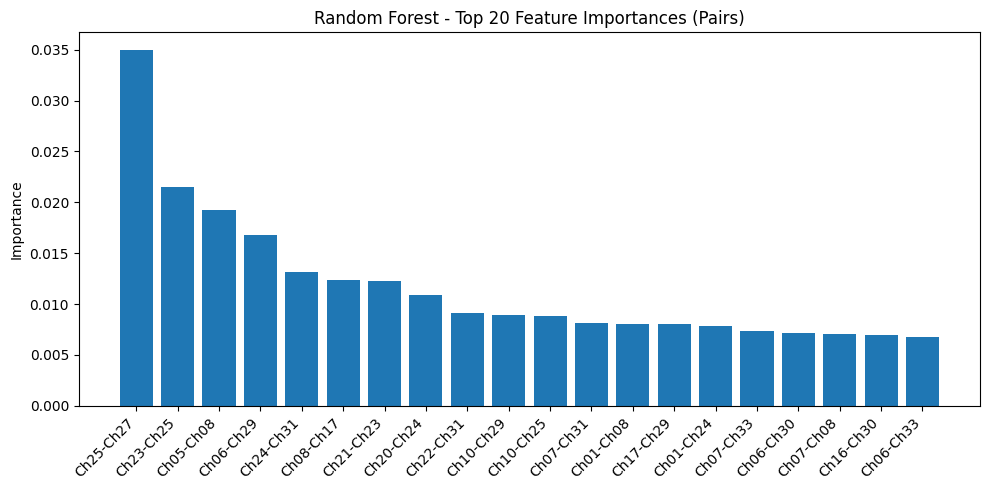

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# rf2 eğitili değilse:
# rf2.fit(X_train_s, y_train)

imp = rf2.feature_importances_
top_n = 20
top_idx = np.argsort(imp)[::-1][:top_n]

print("Top 20 RF Important Features (as electrode pairs):")
for k, fi in enumerate(top_idx, 1):
    print(f"{k:02d}) {feature_names[int(fi)]}   (feature {int(fi)})   RF_imp: {float(imp[fi]):.6f}")

# Plot (Top 20)
plt.figure(figsize=(10,5))
plt.bar(range(top_n), imp[top_idx])
plt.xticks(range(top_n), [feature_names[int(i)] for i in top_idx], rotation=45, ha="right")
plt.title("Random Forest - Top 20 Feature Importances (Pairs)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
import shap
import numpy as np

# rf2 eğitili olmalı (X_train_s ile)
# rf2.fit(X_train_s, y_train)

explainer = shap.Explainer(rf2, X_train_s)   # background=train
sv_obj = explainer(X_train_s)

vals = sv_obj.values   # beklenen: (n_samples, n_features) veya (n_samples, n_features, 2)
if vals.ndim == 3:
    vals = vals[:, :, 1]  # class 1

sv = vals
print("Final sv shape:", sv.shape)  # beklenen: (n_samples, 595)

Final sv shape: (96, 595)


Top 20 SHAP Features (as electrode pairs):
01) Ch25-Ch27   (feature 541)   SHAP: 0.021162
02) Ch05-Ch08   (feature 132)   SHAP: 0.012065
03) Ch23-Ch25   (feature 518)   SHAP: 0.011740
04) Ch06-Ch29   (feature 182)   SHAP: 0.009501
05) Ch20-Ch24   (feature 478)   SHAP: 0.006876
06) Ch24-Ch31   (feature 535)   SHAP: 0.006744
07) Ch21-Ch23   (feature 491)   SHAP: 0.006708
08) Ch10-Ch25   (feature 284)   SHAP: 0.006086
09) Ch08-Ch17   (feature 225)   SHAP: 0.005447
10) Ch07-Ch31   (feature 212)   SHAP: 0.005430
11) Ch13-Ch27   (feature 355)   SHAP: 0.005058
12) Ch17-Ch29   (feature 435)   SHAP: 0.004885
13) Ch10-Ch29   (feature 288)   SHAP: 0.004828
14) Ch22-Ch31   (feature 512)   SHAP: 0.004729
15) Ch01-Ch08   (feature 6)   SHAP: 0.004228
16) Ch16-Ch30   (feature 418)   SHAP: 0.004186
17) Ch07-Ch33   (feature 214)   SHAP: 0.004101
18) Ch01-Ch11   (feature 9)   SHAP: 0.003960
19) Ch08-Ch10   (feature 218)   SHAP: 0.003910
20) Ch06-Ch30   (feature 183)   SHAP: 0.003873


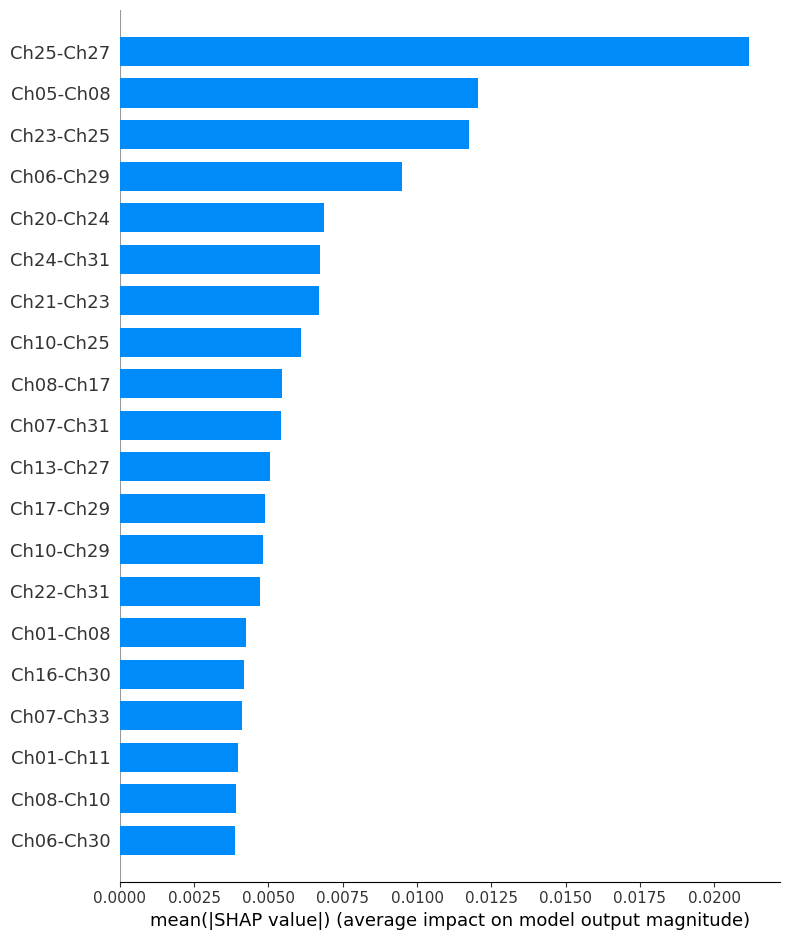

In [ ]:
import numpy as np
import shap

shap_importance = np.abs(sv).mean(axis=0)   # (n_features,)
idx = np.argsort(shap_importance)[::-1]

top_n = 20
print("Top 20 SHAP Features (as electrode pairs):")
for k in range(top_n):
    fi = int(idx[k])
    print(f"{k+1:02d}) {feature_names[fi]}   (feature {fi})   SHAP: {float(shap_importance[fi]):.6f}")

# SHAP plot için feature_names'i verelim:
X_train_named = X_train_s.copy()  # numpy array
shap.summary_plot(sv, X_train_named, feature_names=feature_names, plot_type="bar", max_display=20)

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

rf_pipe = Pipeline([
    ("nanfix", FunctionTransformer(lambda X: np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0))),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_rf = cross_validate(
    rf_pipe, X, y01, cv=cv,
    scoring=["accuracy", "f1", "roc_auc"],
    return_train_score=False
)

print("RF 5-Fold CV Results (PCA)")
print("ACC mean±std:", float(scores_rf["test_accuracy"].mean()), "±", float(scores_rf["test_accuracy"].std()))
print("F1  mean±std:", float(scores_rf["test_f1"].mean()),       "±", float(scores_rf["test_f1"].std()))
print("AUC mean±std:", float(scores_rf["test_roc_auc"].mean()),   "±", float(scores_rf["test_roc_auc"].std()))

RF 5-Fold CV Results (PCA)
ACC mean±std: 0.768 ± 0.06905231511124173
F1  mean±std: 0.8326381461675579 ± 0.0436353351008303
AUC mean±std: 0.9125238095238096 ± 0.028935223612975215


Confusion Matrix:
 [[ 5  5]
 [ 0 15]]

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.5000    0.6667        10
           1     0.7500    1.0000    0.8571        15

    accuracy                         0.8000        25
   macro avg     0.8750    0.7500    0.7619        25
weighted avg     0.8500    0.8000    0.7810        25



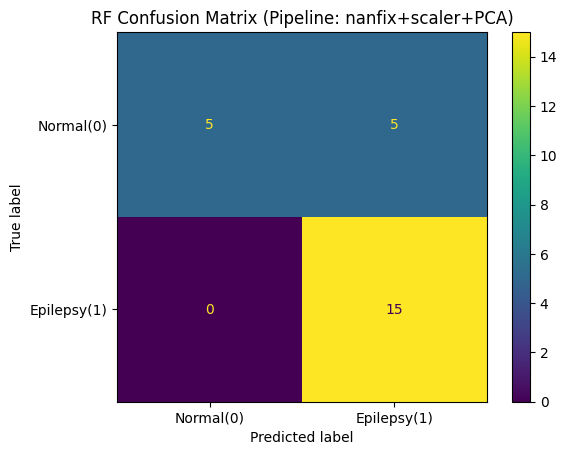

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y01, test_size=0.2, random_state=42, stratify=y01
)

rf_pipe.fit(X_train, y_train)
pred = rf_pipe.predict(X_test)

cm = confusion_matrix(y_test, pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, pred, digits=4))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Epilepsy(1)"])
disp.plot(values_format="d")
plt.title("RF Confusion Matrix (Pipeline: nanfix+scaler+PCA)")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import textwrap

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import confusion_matrix, classification_report

def _safe(name, fn):
    try:
        return True, fn()
    except Exception as e:
        return False, f"[{name}] ERROR: {type(e).__name__}: {e}"

def print_section(title):
    print("\n" + "="*80)
    print(title)
    print("="*80)

def summarize_corr_matrix_from_X(X):
    # X: (n_samples, n_features) = flattened upper-tri corr values
    vals = X.ravel()
    vals = vals[np.isfinite(vals)]
    return float(np.min(vals)), float(np.max(vals)), float(np.mean(vals))

def build_feature_names(good_idx_ref, ch_names=None):
    n = len(good_idx_ref)
    if ch_names is None:
        ch_names = [f"Ch{i+1:02d}" for i in range(n)]
    iu = np.triu_indices(n, k=1)
    feature_names = [f"{ch_names[int(iu[0][k])]}-{ch_names[int(iu[1][k])]}" for k in range(len(iu[0]))]
    return feature_names

def top_from_scores(scores_1d, feature_names, top_n=20):
    scores_1d = np.asarray(scores_1d).reshape(-1)
    idx = np.argsort(scores_1d)[::-1][:top_n]
    df = pd.DataFrame({
        "rank": np.arange(1, top_n+1),
        "feature_idx": idx,
        "feature_name": [feature_names[int(i)] for i in idx],
        "score": scores_1d[idx],
    })
    return df

print_section("EEG PIPELINE SUMMARY REPORT")

# 0) Temel değişkenler var mı?
globals_present = {
    "X": "X" in globals(),
    "y01": "y01" in globals(),
    "good_idx_ref": "good_idx_ref" in globals(),
    "rf2": "rf2" in globals(),
    "rf_pipe": "rf_pipe" in globals(),
    "X_train_s": "X_train_s" in globals(),
    "X_test_s": "X_test_s" in globals(),
    "y_train": "y_train" in globals(),
    "y_test": "y_test" in globals(),
    "sv": "sv" in globals(),  # SHAP values (n_samples, n_features)
}
print("Globals present:", globals_present)

if not globals_present["X"] or not globals_present["y01"] or not globals_present["good_idx_ref"]:
    raise ValueError("X, y01, good_idx_ref olmadan rapor üretilemez. Önce feature extraction kısmını çalıştır.")

X = globals()["X"]
y01 = globals()["y01"]
good_idx_ref = globals()["good_idx_ref"]

# 1) Dataset / sınıflar
print_section("1) Dataset / Classes")
print("X shape:", getattr(X, "shape", None))
print("y shape:", getattr(y01, "shape", None))
classes, counts = np.unique(y01, return_counts=True)
print("Classes:", dict(zip(classes.tolist(), counts.tolist())))

# 2) Feature naming (pair mapping)
print_section("2) Feature Naming (Pair labels)")
feature_names = build_feature_names(good_idx_ref)
print("n_channels (good):", len(good_idx_ref))
print("n_features (pairs):", len(feature_names))
example_idx = [0, 1, 10, min(541, len(feature_names)-1)]
for fi in example_idx:
    print(f"Feature {fi} -> {feature_names[fi]}")

# 3) Min/Max/Mean correlation across ALL features (hocanın/ senin istediğin)
print_section("3) Correlation Stats Across Features (Min/Max/Mean)")
ok, res = _safe("corr_stats", lambda: summarize_corr_matrix_from_X(X))
if ok:
    mn, mx, meanv = res
    print("Corr MIN :", mn)
    print("Corr MAX :", mx)
    print("Corr MEAN:", meanv)
else:
    print(res)

# 4) Hold-out test + Confusion Matrix (rf_pipe varsa onunla, yoksa rf2 ile dener)
print_section("4) Hold-out Evaluation + Confusion Matrix")
def holdout_eval():
    # rf_pipe varsa onu tercih et (nanfix+scaler+pca gibi)
    if "rf_pipe" in globals():
        model = globals()["rf_pipe"]
        # train/test split varsa kullan, yoksa yeniden yap
        if "X_train" in globals() and "X_test" in globals() and "y_train" in globals() and "y_test" in globals():
            Xt, Xv, yt, yv = globals()["X_train"], globals()["X_test"], globals()["y_train"], globals()["y_test"]
        else:
            Xt, Xv, yt, yv = train_test_split(X, y01, test_size=0.2, random_state=42, stratify=y01)
        model.fit(Xt, yt)
        pred = model.predict(Xv)
    else:
        # rf2 varsa (PCA'sız) train_s ile deneyebiliriz
        if "rf2" not in globals() or "X_train_s" not in globals() or "X_test_s" not in globals():
            raise ValueError("Hold-out için rf_pipe yok; rf2 + X_train_s/X_test_s de yok.")
        model = globals()["rf2"]
        Xt, Xv, yt, yv = globals()["X_train_s"], globals()["X_test_s"], globals()["y_train"], globals()["y_test"]
        model.fit(Xt, yt)
        pred = model.predict(Xv)

    cm = confusion_matrix(yv, pred)
    rep = classification_report(yv, pred, digits=4)
    return cm, rep

ok, res = _safe("holdout_eval", holdout_eval)
if ok:
    cm, rep = res
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", rep)
else:
    print(res)

# 5) 5-Fold CV (rf_pipe varsa onunla, yoksa SKIP)
print_section("5) 5-Fold Cross-Validation (ACC / F1 / AUC)")
def cv_eval():
    if "rf_pipe" not in globals():
        raise ValueError("rf_pipe yok. CV için nanfix+scaler+pca pipeline önerilir.")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(
        globals()["rf_pipe"], X, y01, cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        return_train_score=False
    )
    out = {
        "ACC_mean": float(scores["test_accuracy"].mean()),
        "ACC_std" : float(scores["test_accuracy"].std()),
        "F1_mean" : float(scores["test_f1"].mean()),
        "F1_std"  : float(scores["test_f1"].std()),
        "AUC_mean": float(scores["test_roc_auc"].mean()),
        "AUC_std" : float(scores["test_roc_auc"].std()),
    }
    return out

ok, res = _safe("cv_eval", cv_eval)
if ok:
    for k,v in res.items():
        print(f"{k}: {v}")
else:
    print(res)

# 6) RF feature importance (rf2 varsa isimli Top20)
print_section("6) Random Forest Feature Importance (Top 20, named)")
def rf_importance():
    if "rf2" not in globals():
        raise ValueError("rf2 yok.")
    rf2 = globals()["rf2"]
    imp = rf2.feature_importances_
    df = top_from_scores(imp, feature_names, top_n=20)
    return df

ok, res = _safe("rf_importance", rf_importance)
if ok:
    print(res.to_string(index=False))
else:
    print(res)

# 7) SHAP importance (sv varsa Top20 isimli)
print_section("7) SHAP Importance (Top 20, named)")
def shap_importance():
    if "sv" not in globals():
        raise ValueError("sv (SHAP values) yok.")
    sv = globals()["sv"]
    if sv.ndim != 2:
        raise ValueError(f"sv 2D olmalı. sv.ndim={sv.ndim}")
    shap_imp = np.abs(sv).mean(axis=0)
    df = top_from_scores(shap_imp, feature_names, top_n=20)
    return sv.shape, df

ok, res = _safe("shap_importance", shap_importance)
if ok:
    sv_shape, df = res
    print("sv shape:", sv_shape)
    print(df.to_string(index=False))
else:
    print(res)



EEG PIPELINE SUMMARY REPORT
Globals present: {'X': True, 'y01': True, 'good_idx_ref': True, 'rf2': True, 'rf_pipe': True, 'X_train_s': True, 'X_test_s': True, 'y_train': True, 'y_test': True, 'sv': True}

1) Dataset / Classes
X shape: (121, 595)
y shape: (121,)
Classes: {0: 50, 1: 71}

2) Feature Naming (Pair labels)
n_channels (good): 35
n_features (pairs): 595
Feature 0 -> Ch01-Ch02
Feature 1 -> Ch01-Ch03
Feature 10 -> Ch01-Ch12
Feature 541 -> Ch25-Ch27

3) Correlation Stats Across Features (Min/Max/Mean)
Corr MIN : -1.0
Corr MAX : 0.9999999999999998
Corr MEAN: 0.11799635840921019

4) Hold-out Evaluation + Confusion Matrix
Confusion Matrix:
 [[ 5  5]
 [ 0 15]]

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.5000    0.6667        10
           1     0.7500    1.0000    0.8571        15

    accuracy                         0.8000        25
   macro avg     0.8750    0.7500    0.7619        25
weighted avg     0.8500    0.80

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
print("X shape:", X.shape)
print("y01 shape:", y01.shape)
print("Unique classes:", np.unique(y01))

X shape: (121, 595)
y01 shape: (121,)
Unique classes: [0 1]


In [ ]:
def evaluate_model_10fold(model, X, y, model_name="Model"):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        return_train_score=False,
        n_jobs=-1
    )

    acc_mean = float(scores["test_accuracy"].mean())
    acc_std  = float(scores["test_accuracy"].std())

    f1_mean = float(scores["test_f1"].mean())
    f1_std  = float(scores["test_f1"].std())

    auc_mean = float(scores["test_roc_auc"].mean())
    auc_std  = float(scores["test_roc_auc"].std())

    print(f"\n{model_name} - 10 Fold CV Results")
    print(f"Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"F1 Score : {f1_mean:.4f} ± {f1_std:.4f}")
    print(f"ROC-AUC  : {auc_mean:.4f} ± {auc_std:.4f}")

    return {
        "Model": model_name,
        "ACC_mean": acc_mean,
        "ACC_std": acc_std,
        "F1_mean": f1_mean,
        "F1_std": f1_std,
        "AUC_mean": auc_mean,
        "AUC_std": auc_std
    }

In [ ]:
common_steps = [
    ("nanfix", FunctionTransformer(lambda X: np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0))),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42))
]

In [ ]:
logreg_pipe = Pipeline(common_steps + [
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

result_logreg = evaluate_model_10fold(
    logreg_pipe,
    X,
    y01,
    model_name="Logistic Regression"
)


Logistic Regression - 10 Fold CV Results
Accuracy : 0.7942 ± 0.0900
F1 Score : 0.8245 ± 0.0715
ROC-AUC  : 0.9275 ± 0.0509


In [ ]:
ann_pipe = Pipeline(common_steps + [
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=500,
        random_state=42
    ))
])

result_ann = evaluate_model_10fold(
    ann_pipe,
    X,
    y01,
    model_name="ANN (MLP)"
)


ANN (MLP) - 10 Fold CV Results
Accuracy : 0.8346 ± 0.0746
F1 Score : 0.8591 ± 0.0671
ROC-AUC  : 0.8989 ± 0.0728


In [ ]:
rf_pipe = Pipeline(common_steps + [
    ("rf", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

result_rf = evaluate_model_10fold(
    rf_pipe,
    X,
    y01,
    model_name="Random Forest"
)


Random Forest - 10 Fold CV Results
Accuracy : 0.7699 ± 0.0914
F1 Score : 0.8321 ± 0.0612
ROC-AUC  : 0.8746 ± 0.0706


In [ ]:
xgb_pipe = Pipeline(common_steps + [
    ("xgb", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

result_xgb = evaluate_model_10fold(
    xgb_pipe,
    X,
    y01,
    model_name="XGBoost"
)


XGBoost - 10 Fold CV Results
Accuracy : 0.8276 ± 0.1112
F1 Score : 0.8579 ± 0.0887
ROC-AUC  : 0.8789 ± 0.1025


In [ ]:
results_10fold = pd.DataFrame([
    result_logreg,
    result_ann,
    result_rf,
    result_xgb
])

results_10fold = results_10fold.sort_values(
    by=["AUC_mean", "F1_mean", "ACC_mean"],
    ascending=False
).reset_index(drop=True)

print("\n================ FINAL 10-FOLD COMPARISON TABLE ================\n")
print(results_10fold.round(4))


================ FINAL 10-FOLD COMPARISON TABLE ================

                 Model  ACC_mean  ACC_std  F1_mean  F1_std  AUC_mean  AUC_std
0  Logistic Regression    0.7942   0.0900   0.8245  0.0715    0.9275   0.0509
1            ANN (MLP)    0.8346   0.0746   0.8591  0.0671    0.8989   0.0728
2              XGBoost    0.8276   0.1112   0.8579  0.0887    0.8789   0.1025
3        Random Forest    0.7699   0.0914   0.8321  0.0612    0.8746   0.0706


In [ ]:

paper_compare = results_10fold.copy()


paper_compare["ACC_%"] = paper_compare["ACC_mean"] * 100
paper_compare["F1_%"]  = paper_compare["F1_mean"] * 100
paper_compare["AUC_%"] = paper_compare["AUC_mean"] * 100

# paper accuracy referansı
paper_acc = 85.0

# paper'a göre fark
paper_compare["ACC_Diff_vs_Paper"] = paper_compare["ACC_%"] - paper_acc

# model tipleri
model_type_map = {
    "Logistic Regression": "Linear ML",
    "ANN (MLP)": "Simple ANN",
    "Random Forest": "Tree-Based ML",
    "XGBoost": "Boosted Tree ML"
}

paper_compare["Model_Type"] = paper_compare["Model"].map(model_type_map)
paper_compare["Validation"] = "10-Fold CV"
paper_compare["Reference"] = "Our Study"


paper_compare_view = paper_compare[[
    "Model",
    "Model_Type",
    "Validation",
    "ACC_%",
    "ACC_Diff_vs_Paper",
    "F1_%",
    "AUC_%",
    "Reference"
]].copy()

# paper satırı
paper_row = pd.DataFrame([{
    "Model": "EpilepsyNet",
    "Model_Type": "Transformer",
    "Validation": "10-Fold CV",
    "ACC_%": 85.0,
    "ACC_Diff_vs_Paper": 0.0,
    "F1_%": np.nan,
    "AUC_%": np.nan,
    "Reference": "Paper"
}])

# birleştir
final_compare_table = pd.concat([paper_compare_view, paper_row], ignore_index=True)

# sıralama: önce bizim modeller, en alta paper
final_compare_table["sort_key"] = final_compare_table["Reference"].apply(
    lambda x: 1 if x == "Paper" else 0
)
final_compare_table = final_compare_table.sort_values(
    by=["sort_key", "ACC_%"],
    ascending=[True, False]
).drop(columns="sort_key").reset_index(drop=True)

final_compare_table["ACC_%"] = final_compare_table["ACC_%"].map(
    lambda x: f"{x:.2f}"
)

final_compare_table["ACC_Diff_vs_Paper"] = final_compare_table["ACC_Diff_vs_Paper"].map(
    lambda x: f"{x:+.2f}"
)

final_compare_table["F1_%"] = final_compare_table["F1_%"].map(
    lambda x: "-" if pd.isna(x) else f"{x:.2f}"
)

final_compare_table["AUC_%"] = final_compare_table["AUC_%"].map(
    lambda x: "-" if pd.isna(x) else f"{x:.2f}"
)

print("\n EPILEPSYNET PAPER COMPARISON TABLE \n")
print(final_compare_table.to_string(index=False))


 EPILEPSYNET PAPER COMPARISON TABLE 

              Model      Model_Type Validation ACC_% ACC_Diff_vs_Paper  F1_% AUC_% Reference
          ANN (MLP)      Simple ANN 10-Fold CV 83.46             -1.54 85.91 89.89 Our Study
            XGBoost Boosted Tree ML 10-Fold CV 82.76             -2.24 85.79 87.89 Our Study
Logistic Regression       Linear ML 10-Fold CV 79.42             -5.58 82.45 92.75 Our Study
      Random Forest   Tree-Based ML 10-Fold CV 76.99             -8.01 83.21 87.46 Our Study
        EpilepsyNet     Transformer 10-Fold CV 85.00             +0.00     -     -     Paper


In [ ]:


print("\n SUMMARY(EPINET) \n")

for _, row in final_compare_table.iterrows():
    if row["Reference"] == "Our Study":
        diff = float(row["ACC_Diff_vs_Paper"])
        if diff > 0:
            status = "Paper'dan DAHA YUKSEK"
        elif diff < 0:
            status = "Paper'dan DAHA DUSUK"
        else:
            status = "Paper ile AYNI"

        print(f"{row['Model']}: Accuracy = {row['ACC_%']} | Paper farkı = {row['ACC_Diff_vs_Paper']} -> {status}")


 SUMMARY(EPINET) 

ANN (MLP): Accuracy = 83.46 | Paper farkı = -1.54 -> Paper'dan DAHA DUSUK
XGBoost: Accuracy = 82.76 | Paper farkı = -2.24 -> Paper'dan DAHA DUSUK
Logistic Regression: Accuracy = 79.42 | Paper farkı = -5.58 -> Paper'dan DAHA DUSUK
Random Forest: Accuracy = 76.99 | Paper farkı = -8.01 -> Paper'dan DAHA DUSUK


[INFO] Channel count inferred from 'C_diff': 35

[FINAL CHANNEL NAMES USED]
01 -> FP1A1
02 -> FP2A2
03 -> F3A1
04 -> F4A2
05 -> FZA2
06 -> C3A1
07 -> C4A2
08 -> CZA1
09 -> P3A1
10 -> P4A2
11 -> PZA2
12 -> O1A1
13 -> O2A2
14 -> F7A1
15 -> F8A1
16 -> T3A1
17 -> T4A2
18 -> T5A1
19 -> T6A2
20 -> FP1F7
21 -> F7T3
22 -> T3T5
23 -> T5O1
24 -> FP1F3
25 -> F3C3
26 -> C3P3
27 -> P3O1
28 -> P2P4
29 -> F4C4
30 -> C4P4
31 -> P4O2
32 -> FP2F8
33 -> F8T4
34 -> T4T6
35 -> T6O2
[OK] Created relabeled version: C_diff_named

[INFO] Number of generated pair-features: 595


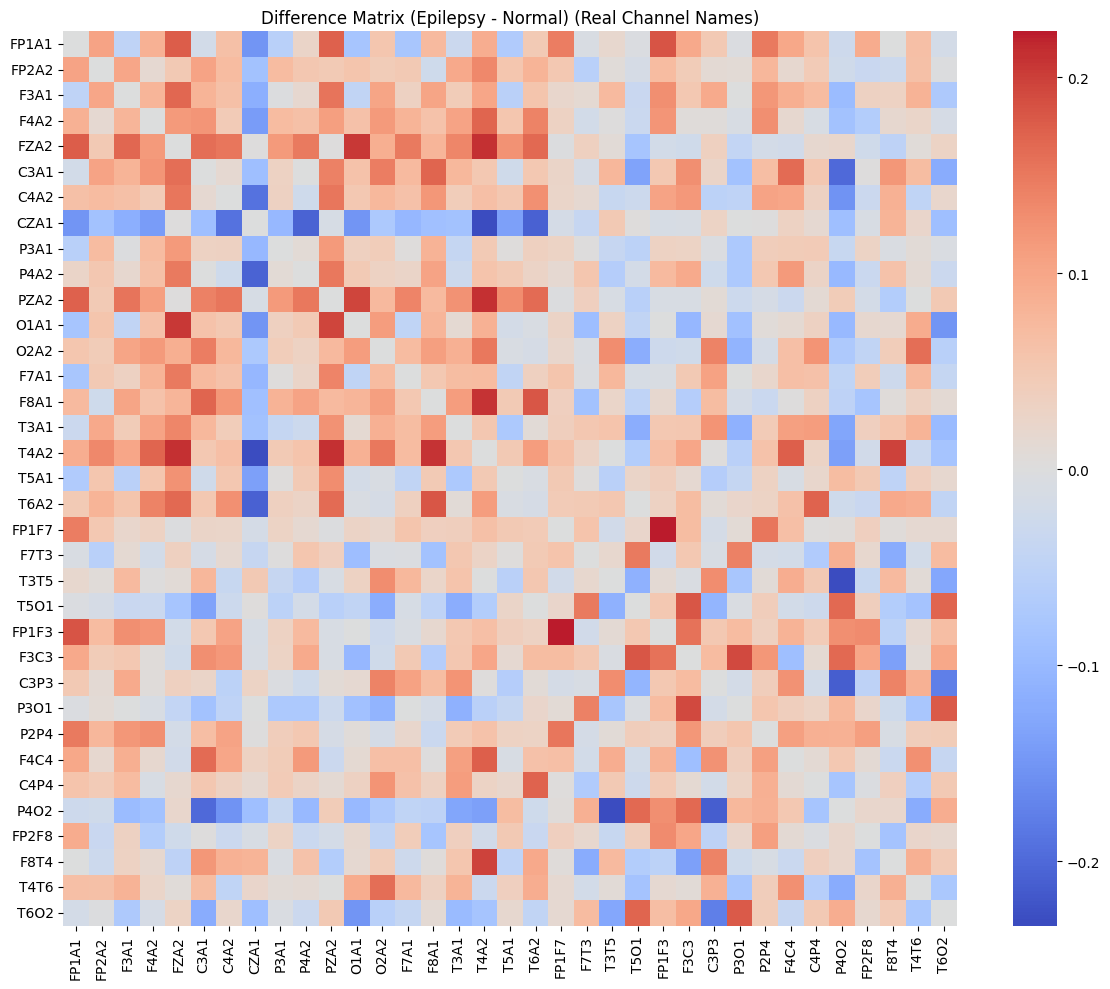


[CHANNEL MAPPING TABLE]


,Old_Label,Real_Channel_Name
0,Ch01,FP1A1
1,Ch02,FP2A2
2,Ch03,F3A1
3,Ch04,F4A2
4,Ch05,FZA2
5,Ch06,C3A1
6,Ch07,C4A2
7,Ch08,CZA1
8,Ch09,P3A1
9,Ch10,P4A2



[DONE] Relabeling block finished.
Files saved:
- channel_mapping_table.csv
- pair_feature_names.csv


In [ ]:
# ============================================================
# APPEND-ONLY BLOCK
# Channel relabeling according to the advisor's TABLE I
# Do NOT change previous code; just run this at the end.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ------------------------------------------------------------
# 1) CHANNEL ORDER FROM TABLE I
# Assumption:
# Your 35 final channels follow the same order as the table.
# ------------------------------------------------------------
table1_channel_names = [
    "FP1A1", "FP2A2", "F3A1", "F4A2", "FZA2",
    "C3A1", "C4A2", "CZA1", "P3A1", "P4A2",
    "PZA2", "O1A1", "O2A2", "F7A1", "F8A1",
    "T3A1", "T4A2", "T5A1", "T6A2",
    "FP1F7", "F7T3", "T3T5", "T5O1",
    "FP1F3", "F3C3", "C3P3", "P3O1",
    "P2P4", "F4C4", "C4P4", "P4O2",
    "FP2F8", "F8T4", "T4T6", "T6O2"
]

# ------------------------------------------------------------
# 2) FIND HOW MANY CHANNELS YOU CURRENTLY HAVE
# We try to infer from existing variables.
# ------------------------------------------------------------
n_channels_detected = None

candidate_mats = [
    "avg_corr_normal", "avg_corr_epilepsy", "C_diff",
    "avg_normal_corr", "avg_epileptic_corr", "diff_corr",
    "corr_normal_mean", "corr_epilepsy_mean"
]

for var_name in candidate_mats:
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, (np.ndarray, pd.DataFrame)) and len(np.shape(obj)) == 2:
            if np.shape(obj)[0] == np.shape(obj)[1]:
                n_channels_detected = np.shape(obj)[0]
                print(f"[INFO] Channel count inferred from '{var_name}': {n_channels_detected}")
                break

if n_channels_detected is None:
    print("[WARNING] Could not infer channel count automatically.")
    print("[INFO] Assuming final channel count = 35")
    n_channels_detected = 35

# ------------------------------------------------------------
# 3) HANDLE POSSIBLE 35-CHANNEL FINAL CASE
# If exactly 35 -> use all names directly
# If fewer -> trim
# If more -> take first n (only as fallback)
# ------------------------------------------------------------
if n_channels_detected <= len(table1_channel_names):
    final_channel_names = table1_channel_names[:n_channels_detected]
else:
    # fallback only
    final_channel_names = table1_channel_names + [f"ExtraCh{i}" for i in range(len(table1_channel_names)+1, n_channels_detected+1)]

print("\n[FINAL CHANNEL NAMES USED]")
for i, ch in enumerate(final_channel_names, start=1):
    print(f"{i:02d} -> {ch}")

# ------------------------------------------------------------
# 4) RELABEL CORRELATION MATRICES IF THEY EXIST
# ------------------------------------------------------------
def relabel_square_matrix(mat, labels):
    if isinstance(mat, np.ndarray):
        df = pd.DataFrame(mat, index=labels, columns=labels)
    elif isinstance(mat, pd.DataFrame):
        df = mat.copy()
        if df.shape[0] == len(labels) and df.shape[1] == len(labels):
            df.index = labels
            df.columns = labels
    else:
        return mat
    return df

matrix_vars_to_relabel = [
    "avg_corr_normal", "avg_corr_epilepsy", "C_diff",
    "avg_normal_corr", "avg_epileptic_corr", "diff_corr",
    "corr_normal_mean", "corr_epilepsy_mean"
]

for var_name in matrix_vars_to_relabel:
    if var_name in globals():
        try:
            globals()[var_name + "_named"] = relabel_square_matrix(globals()[var_name], final_channel_names)
            print(f"[OK] Created relabeled version: {var_name}_named")
        except Exception as e:
            print(f"[SKIP] Could not relabel {var_name}: {e}")

# ------------------------------------------------------------
# 5) BUILD CORRELATION FEATURE NAMES IN THE SAME UPPER-TRIANGLE ORDER
# Example: FP1A1__FP2A2, FP1A1__F3A1, ...
# Total should be nC2 = 595 when n=35
# ------------------------------------------------------------
pair_feature_names = []
pair_feature_map = []  # keeps tuple form too

for i in range(len(final_channel_names)):
    for j in range(i+1, len(final_channel_names)):
        pair_name = f"{final_channel_names[i]}__{final_channel_names[j]}"
        pair_feature_names.append(pair_name)
        pair_feature_map.append((final_channel_names[i], final_channel_names[j]))

print(f"\n[INFO] Number of generated pair-features: {len(pair_feature_names)}")

# Optional pretty DataFrame of all pair features
pair_feature_df = pd.DataFrame(pair_feature_map, columns=["Channel_1", "Channel_2"])
pair_feature_df["Pair_Name"] = pair_feature_names

# ------------------------------------------------------------
# 6) HELPER: convert old Ch-based pair strings to real names
# Example:
#   Ch25__Ch27
#   Ch25-Ch27
#   (Ch25, Ch27)
# ------------------------------------------------------------
def ch_to_real_name(ch_text):
    m = re.match(r"Ch(\d+)", str(ch_text), flags=re.IGNORECASE)
    if m:
        idx = int(m.group(1)) - 1
        if 0 <= idx < len(final_channel_names):
            return final_channel_names[idx]
    return ch_text

def replace_ch_pair_text(text):
    text = str(text)
    matches = re.findall(r"Ch\d+", text, flags=re.IGNORECASE)
    for mch in matches:
        real = ch_to_real_name(mch)
        text = text.replace(mch, str(real))
    return text

# ------------------------------------------------------------
# 7) IF YOU HAVE FEATURE IMPORTANCE ARRAY FOR 595 FEATURES,
# convert it into a named table
#
# Works if one of these exists:
#   rf_importances
#   importances
#   feature_importances
# ------------------------------------------------------------
importance_candidates = ["rf_importances", "importances", "feature_importances"]

named_importance_df = None
for var_name in importance_candidates:
    if var_name in globals():
        arr = np.array(globals()[var_name]).flatten()
        if len(arr) == len(pair_feature_names):
            named_importance_df = pd.DataFrame({
                "Pair_Name": pair_feature_names,
                "Importance": arr
            }).sort_values("Importance", ascending=False).reset_index(drop=True)
            print(f"[OK] Created named_importance_df from '{var_name}'")
            break

if named_importance_df is not None:
    print("\nTop 20 RF/feature importance pairs (real names):")
    display(named_importance_df.head(20))

    plt.figure(figsize=(10, 6))
    topn = min(15, len(named_importance_df))
    sns.barplot(
        data=named_importance_df.head(topn),
        y="Pair_Name",
        x="Importance"
    )
    plt.title("Top Important Correlation Features (Real Channel Names)")
    plt.xlabel("Importance")
    plt.ylabel("Channel Pair")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8) IF YOU HAVE A TOP FEATURES TABLE ALREADY, rename its text
# Works for DataFrames that contain Ch-based labels
# ------------------------------------------------------------
top_df_candidates = [
    "top_features_df", "top_pairs_df", "important_pairs_df",
    "rf_top_df", "shap_top_df", "top_changed_pairs_df"
]

for var_name in top_df_candidates:
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, pd.DataFrame):
            renamed_df = obj.copy()
            for col in renamed_df.columns:
                renamed_df[col] = renamed_df[col].astype(str).apply(replace_ch_pair_text)
            globals()[var_name + "_named"] = renamed_df
            print(f"[OK] Created relabeled table: {var_name}_named")
            display(renamed_df.head(20))

# ------------------------------------------------------------
# 9) IF SHAP VALUES EXIST FOR THE 595 FEATURE SPACE,
# create named SHAP summary table
#
# Supported variable names:
#   shap_values
#   shap_vals
#   shap_array
# ------------------------------------------------------------
shap_candidates = ["shap_values", "shap_vals", "shap_array"]

named_shap_df = None

for var_name in shap_candidates:
    if var_name in globals():
        sv = globals()[var_name]

        # case A: shap values is list (binary classifiers sometimes)
        if isinstance(sv, list):
            try:
                sv_arr = np.array(sv[-1])
            except:
                continue
        else:
            sv_arr = np.array(sv)

        # expected shape: (n_samples, n_features)
        if sv_arr.ndim == 2 and sv_arr.shape[1] == len(pair_feature_names):
            mean_abs_shap = np.mean(np.abs(sv_arr), axis=0)
            named_shap_df = pd.DataFrame({
                "Pair_Name": pair_feature_names,
                "MeanAbsSHAP": mean_abs_shap
            }).sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)
            print(f"[OK] Created named_shap_df from '{var_name}'")
            break

if named_shap_df is not None:
    print("\nTop 20 SHAP pairs (real names):")
    display(named_shap_df.head(20))

    plt.figure(figsize=(10, 6))
    topn = min(15, len(named_shap_df))
    sns.barplot(
        data=named_shap_df.head(topn),
        y="Pair_Name",
        x="MeanAbsSHAP"
    )
    plt.title("Top SHAP Features (Real Channel Names)")
    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Channel Pair")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 10) RE-PLOT RELABELED CORRELATION HEATMAPS IF AVAILABLE
# ------------------------------------------------------------
heatmap_candidates = [
    ("avg_corr_normal_named", "Average Correlation Matrix - NORMAL (Real Channel Names)"),
    ("avg_corr_epilepsy_named", "Average Correlation Matrix - EPILEPSY (Real Channel Names)"),
    ("avg_normal_corr_named", "Average Correlation Matrix - NORMAL (Real Channel Names)"),
    ("avg_epileptic_corr_named", "Average Correlation Matrix - EPILEPSY (Real Channel Names)"),
    ("C_diff_named", "Difference Matrix (Epilepsy - Normal) (Real Channel Names)"),
    ("diff_corr_named", "Difference Matrix (Epilepsy - Normal) (Real Channel Names)")
]

for var_name, title in heatmap_candidates:
    if var_name in globals():
        dfm = globals()[var_name]
        if isinstance(dfm, pd.DataFrame):
            plt.figure(figsize=(12, 10))
            sns.heatmap(dfm, cmap="viridis", center=0)
            plt.title(title)
            plt.tight_layout()
            plt.show()

# ------------------------------------------------------------
# 11) CREATE A DIRECT CHANNEL MAPPING TABLE FOR YOUR PAPER
# ------------------------------------------------------------
channel_mapping_df = pd.DataFrame({
    "Old_Label": [f"Ch{i:02d}" for i in range(1, len(final_channel_names)+1)],
    "Real_Channel_Name": final_channel_names
})

print("\n[CHANNEL MAPPING TABLE]")
display(channel_mapping_df)

# ------------------------------------------------------------
# 12) OPTIONAL: SAVE MAPPING + TOP TABLES
# ------------------------------------------------------------
channel_mapping_df.to_csv("channel_mapping_table.csv", index=False)
pair_feature_df.to_csv("pair_feature_names.csv", index=False)

if named_importance_df is not None:
    named_importance_df.to_csv("rf_importance_named.csv", index=False)

if named_shap_df is not None:
    named_shap_df.to_csv("shap_named.csv", index=False)

print("\n[DONE] Relabeling block finished.")
print("Files saved:")
print("- channel_mapping_table.csv")
print("- pair_feature_names.csv")
if named_importance_df is not None:
    print("- rf_importance_named.csv")
if named_shap_df is not None:
    print("- shap_named.csv")

Final Channel Names:
Ch01 -> FP1A1
Ch02 -> FP2A2
Ch03 -> F3A1
Ch04 -> F4A2
Ch05 -> FZA2
Ch06 -> C3A1
Ch07 -> C4A2
Ch08 -> CZA1
Ch09 -> P3A1
Ch10 -> P4A2
Ch11 -> PZA2
Ch12 -> O1A1
Ch13 -> O2A2
Ch14 -> F7A1
Ch15 -> F8A1
Ch16 -> T3A1
Ch17 -> T4A2
Ch18 -> T5A1
Ch19 -> T6A2
Ch20 -> FP1F7
Ch21 -> F7T3
Ch22 -> T3T5
Ch23 -> T5O1
Ch24 -> FP1F3
Ch25 -> F3C3
Ch26 -> C3P3
Ch27 -> P3O1
Ch28 -> P2P4
Ch29 -> F4C4
Ch30 -> C4P4
Ch31 -> P4O2
Ch32 -> FP2F8
Ch33 -> F8T4
Ch34 -> T4T6
Ch35 -> T6O2


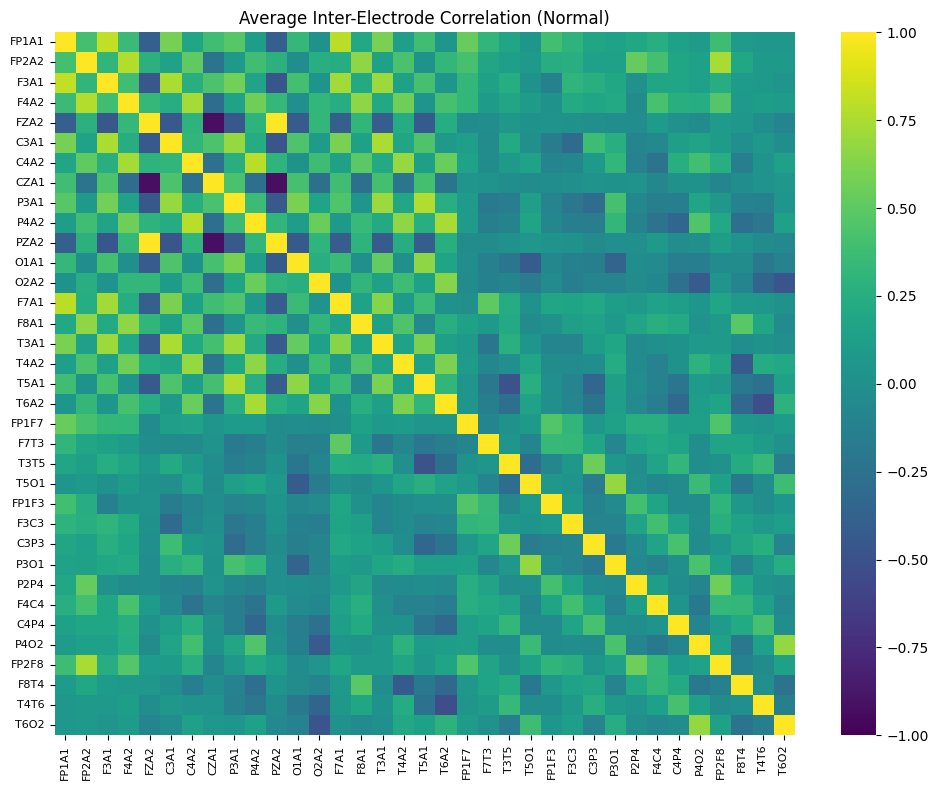

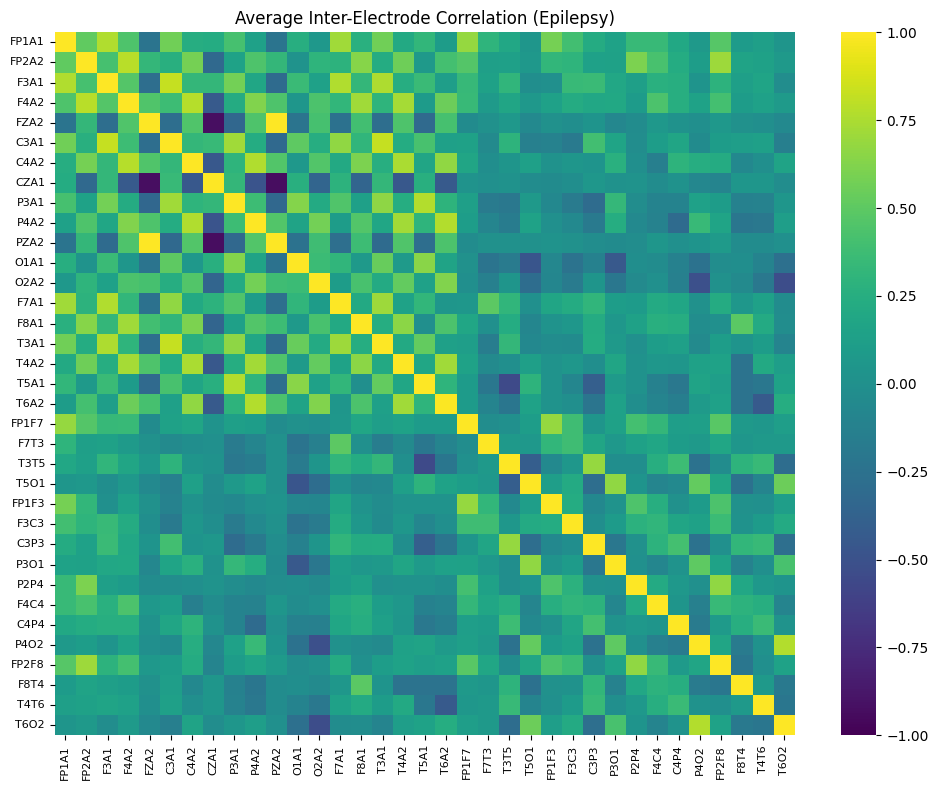

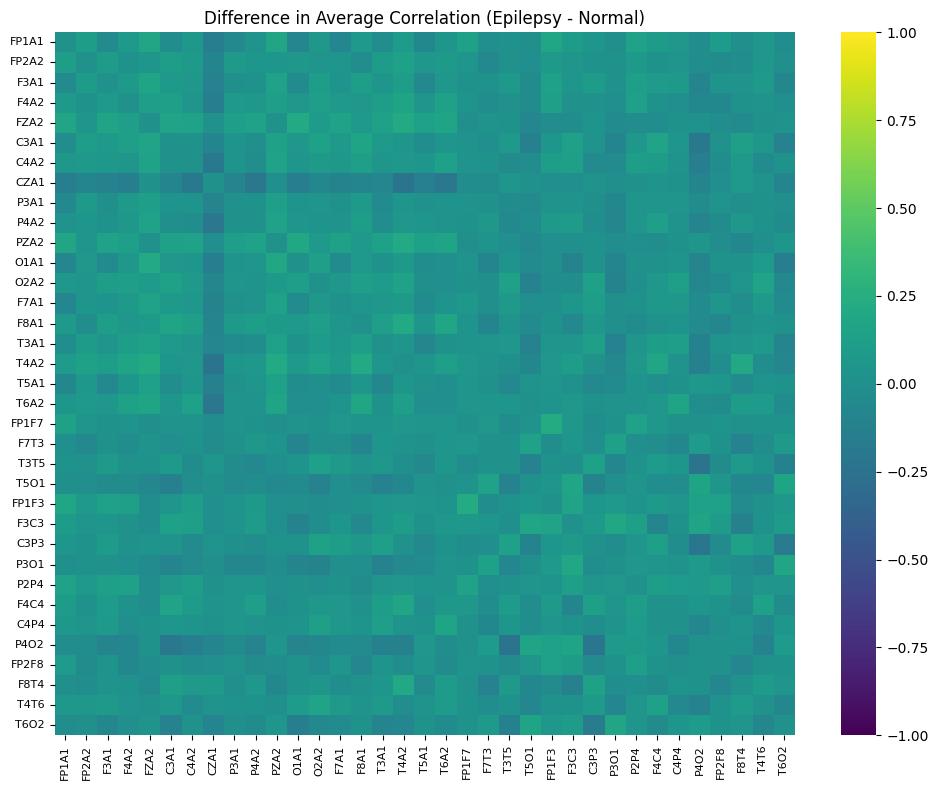


Top-10 Normal (by |corr|)
('FZA2', 'PZA2', 0.9923452881213082, 0.9923452881213082)
('FZA2', 'CZA1', -0.9274739406961295, 0.9274739406961295)
('CZA1', 'PZA2', -0.9240591827474218, 0.9240591827474218)
('FP1A1', 'F3A1', 0.81131391312448, 0.81131391312448)
('FP1A1', 'F7A1', 0.7912635483099502, 0.7912635483099502)
('C4A2', 'P4A2', 0.78457514772631, 0.78457514772631)
('FP2A2', 'F4A2', 0.7688448239066068, 0.7688448239066068)
('P3A1', 'T5A1', 0.762944618867835, 0.762944618867835)
('C3A1', 'T3A1', 0.7453540371531987, 0.7453540371531987)
('F3A1', 'C3A1', 0.742689696452084, 0.742689696452084)


,Electrode_1,Electrode_2,Correlation,AbsCorrelation
0,FZA2,PZA2,0.992345,0.992345
1,FZA2,CZA1,-0.927474,0.927474
2,CZA1,PZA2,-0.924059,0.924059
3,FP1A1,F3A1,0.811314,0.811314
4,FP1A1,F7A1,0.791264,0.791264
5,C4A2,P4A2,0.784575,0.784575
6,FP2A2,F4A2,0.768845,0.768845
7,P3A1,T5A1,0.762945,0.762945
8,C3A1,T3A1,0.745354,0.745354
9,F3A1,C3A1,0.742690,0.742690


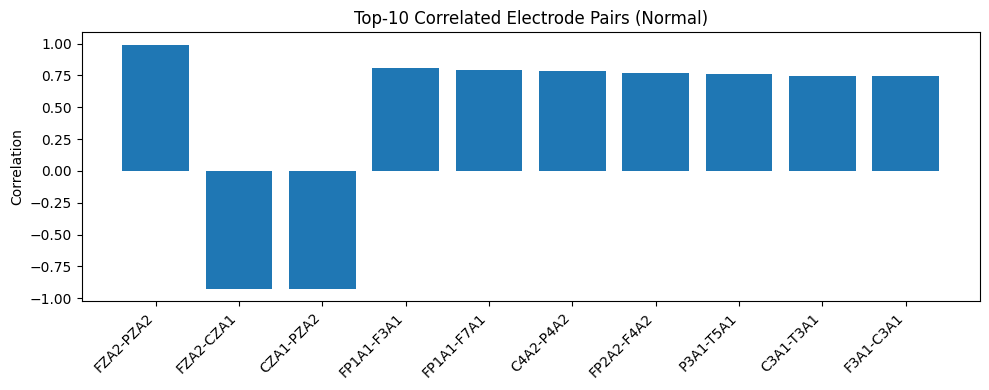


Top-10 Epilepsy (by |corr|)
('FZA2', 'PZA2', 0.994421307556917, 0.994421307556917)
('CZA1', 'PZA2', -0.9369704595675906, 0.9369704595675906)
('FZA2', 'CZA1', -0.9265828360378637, 0.9265828360378637)
('F3A1', 'C3A1', 0.8244962441977746, 0.8244962441977746)
('C3A1', 'T3A1', 0.8213246223753015, 0.8213246223753015)
('FP2A2', 'F4A2', 0.7851470656061967, 0.7851470656061967)
('F4A2', 'C4A2', 0.7781159953596912, 0.7781159953596912)
('P4O2', 'T6O2', 0.7694601022066443, 0.7694601022066443)
('P4A2', 'T6A2', 0.7693164416880303, 0.7693164416880303)
('P3A1', 'T5A1', 0.7659802401458089, 0.7659802401458089)


,Electrode_1,Electrode_2,Correlation,AbsCorrelation
0,FZA2,PZA2,0.994421,0.994421
1,CZA1,PZA2,-0.936970,0.936970
2,FZA2,CZA1,-0.926583,0.926583
3,F3A1,C3A1,0.824496,0.824496
4,C3A1,T3A1,0.821325,0.821325
5,FP2A2,F4A2,0.785147,0.785147
6,F4A2,C4A2,0.778116,0.778116
7,P4O2,T6O2,0.769460,0.769460
8,P4A2,T6A2,0.769316,0.769316
9,P3A1,T5A1,0.765980,0.765980


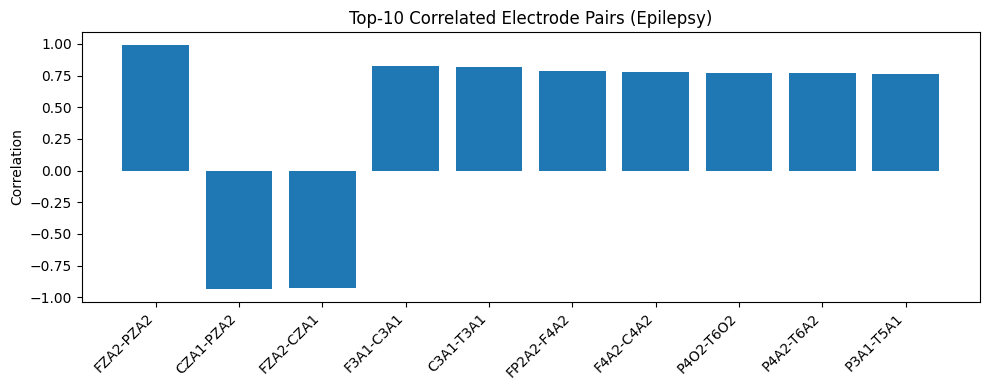


Top-10 Most Changed Pairs (Δcorr: Epilepsy - Normal)
('T3T5', 'P4O2', -0.23282127362970426, 0.23282127362970426)
('CZA1', 'T4A2', -0.2309160874477692, 0.2309160874477692)
('FP1F7', 'FP1F3', 0.22354263172412137, 0.22354263172412137)
('C3P3', 'P4O2', -0.212381248740804, 0.212381248740804)
('FZA2', 'T4A2', 0.21183801407078484, 0.21183801407078484)
('CZA1', 'T6A2', -0.20937334308451533, 0.20937334308451533)
('PZA2', 'T4A2', 0.2093221397970292, 0.2093221397970292)
('F8A1', 'T4A2', 0.20751941546114605, 0.20751941546114605)
('CZA1', 'P4A2', -0.20613286977937562, 0.20613286977937562)
('FZA2', 'O1A1', 0.20556621798484595, 0.20556621798484595)


,Electrode_1,Electrode_2,DeltaCorrelation,AbsDeltaCorrelation
0,T3T5,P4O2,-0.232821,0.232821
1,CZA1,T4A2,-0.230916,0.230916
2,FP1F7,FP1F3,0.223543,0.223543
3,C3P3,P4O2,-0.212381,0.212381
4,FZA2,T4A2,0.211838,0.211838
5,CZA1,T6A2,-0.209373,0.209373
6,PZA2,T4A2,0.209322,0.209322
7,F8A1,T4A2,0.207519,0.207519
8,CZA1,P4A2,-0.206133,0.206133
9,FZA2,O1A1,0.205566,0.205566


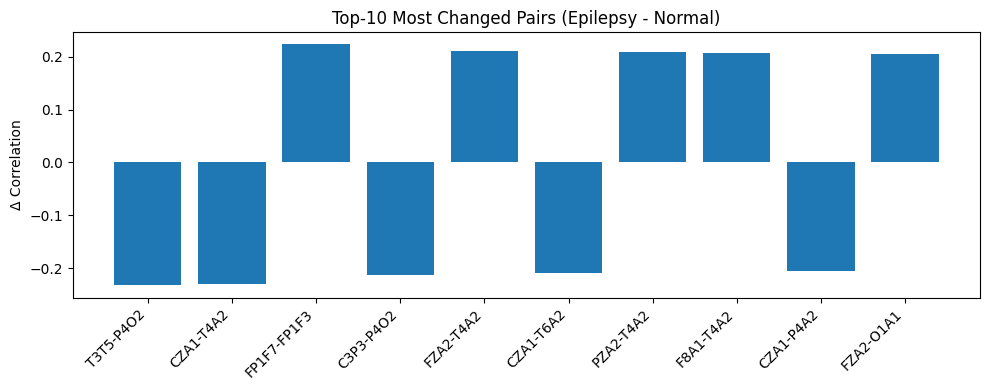


n_channels: 35 | n_features: 595
Feature 0 name: FP1A1-FP2A2
Feature 541 name: F3C3-P3O1


,FeatureIndex,FeatureName,Electrode_1,Electrode_2
0,0,FP1A1-FP2A2,FP1A1,FP2A2
1,1,FP1A1-F3A1,FP1A1,F3A1
2,2,FP1A1-F4A2,FP1A1,F4A2
3,3,FP1A1-FZA2,FP1A1,FZA2
4,4,FP1A1-C3A1,FP1A1,C3A1
5,5,FP1A1-C4A2,FP1A1,C4A2
6,6,FP1A1-CZA1,FP1A1,CZA1
7,7,FP1A1-P3A1,FP1A1,P3A1
8,8,FP1A1-P4A2,FP1A1,P4A2
9,9,FP1A1-PZA2,FP1A1,PZA2



Top 20 RF Important Features
01) F3C3-P3O1   (feature 541)   RF_imp: 0.034956
02) T5O1-F3C3   (feature 518)   RF_imp: 0.021504
03) FZA2-CZA1   (feature 132)   RF_imp: 0.019277
04) C3A1-F4C4   (feature 182)   RF_imp: 0.016788
05) FP1F3-P4O2   (feature 535)   RF_imp: 0.013124
06) CZA1-T4A2   (feature 225)   RF_imp: 0.012364
07) F7T3-T5O1   (feature 491)   RF_imp: 0.012252
08) FP1F7-FP1F3   (feature 478)   RF_imp: 0.010920
09) T3T5-P4O2   (feature 512)   RF_imp: 0.009165
10) P4A2-F4C4   (feature 288)   RF_imp: 0.008900
11) P4A2-F3C3   (feature 284)   RF_imp: 0.008854
12) C4A2-P4O2   (feature 212)   RF_imp: 0.008131
13) FP1A1-CZA1   (feature 6)   RF_imp: 0.008089
14) T4A2-F4C4   (feature 435)   RF_imp: 0.008030
15) FP1A1-FP1F3   (feature 22)   RF_imp: 0.007846
16) C4A2-F8T4   (feature 214)   RF_imp: 0.007357
17) C3A1-C4P4   (feature 183)   RF_imp: 0.007184
18) C4A2-CZA1   (feature 189)   RF_imp: 0.007015
19) T3A1-C4P4   (feature 418)   RF_imp: 0.006934
20) C3A1-F8T4   (feature 186)   RF_i

,Rank,FeatureIndex,FeatureName,RFImportance
0,1,541,F3C3-P3O1,0.034956
1,2,518,T5O1-F3C3,0.021504
2,3,132,FZA2-CZA1,0.019277
3,4,182,C3A1-F4C4,0.016788
4,5,535,FP1F3-P4O2,0.013124
5,6,225,CZA1-T4A2,0.012364
6,7,491,F7T3-T5O1,0.012252
7,8,478,FP1F7-FP1F3,0.010920
8,9,512,T3T5-P4O2,0.009165
9,10,288,P4A2-F4C4,0.008900


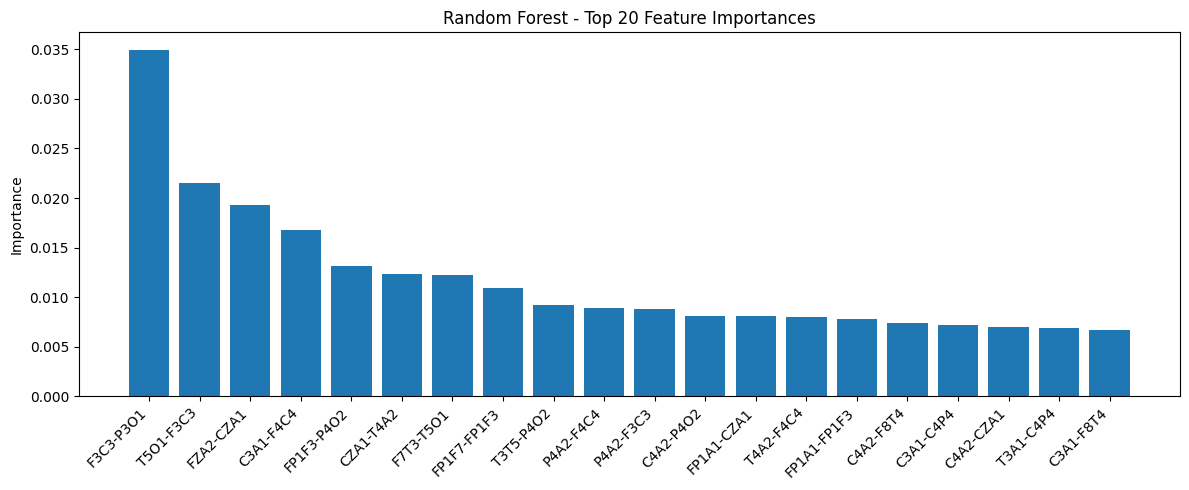


Top 20 SHAP Features
01) F3C3-P3O1   (feature 541)   SHAP: 0.021003
02) T5O1-F3C3   (feature 518)   SHAP: 0.015765
03) FZA2-CZA1   (feature 132)   SHAP: 0.011893
04) C3A1-F4C4   (feature 182)   SHAP: 0.010547
05) FP1F3-P4O2   (feature 535)   SHAP: 0.009024
06) FP1F7-FP1F3   (feature 478)   SHAP: 0.007901
07) T3T5-P4O2   (feature 512)   SHAP: 0.007048
08) O2A2-P3O1   (feature 355)   SHAP: 0.006932
09) F7T3-T5O1   (feature 491)   SHAP: 0.006216
10) T3A1-C4P4   (feature 418)   SHAP: 0.006216
11) T4A2-F4C4   (feature 435)   SHAP: 0.006109
12) CZA1-T4A2   (feature 225)   SHAP: 0.006023
13) P3O1-T6O2   (feature 566)   SHAP: 0.005343
14) C4A2-CZA1   (feature 189)   SHAP: 0.005061
15) C4A2-P4O2   (feature 212)   SHAP: 0.005018
16) F3C3-P4O2   (feature 545)   SHAP: 0.004941
17) P4A2-F3C3   (feature 284)   SHAP: 0.004564
18) CZA1-P4O2   (feature 239)   SHAP: 0.004461
19) CZA1-T6O2   (feature 243)   SHAP: 0.004304
20) C4A2-F3C3   (feature 206)   SHAP: 0.004231


,Rank,FeatureIndex,FeatureName,MeanAbsSHAP
0,1,541,F3C3-P3O1,0.021003
1,2,518,T5O1-F3C3,0.015765
2,3,132,FZA2-CZA1,0.011893
3,4,182,C3A1-F4C4,0.010547
4,5,535,FP1F3-P4O2,0.009024
5,6,478,FP1F7-FP1F3,0.007901
6,7,512,T3T5-P4O2,0.007048
7,8,355,O2A2-P3O1,0.006932
8,9,491,F7T3-T5O1,0.006216
9,10,418,T3A1-C4P4,0.006216


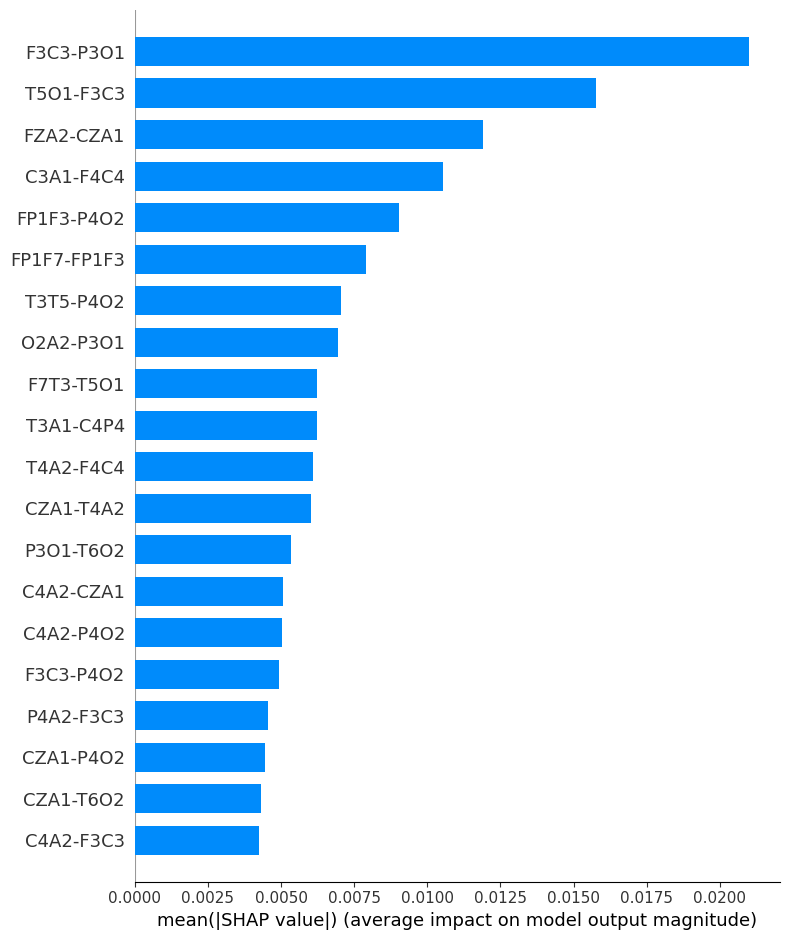


Channel mapping table:


,OldCode,RealName
0,Ch01,FP1A1
1,Ch02,FP2A2
2,Ch03,F3A1
3,Ch04,F4A2
4,Ch05,FZA2
5,Ch06,C3A1
6,Ch07,C4A2
7,Ch08,CZA1
8,Ch09,P3A1
9,Ch10,P4A2



[DONE] All meaningful naming-dependent results were re-generated with real electrode names.
Saved files:
- channel_mapping_real.csv
- feature_map_real.csv
- top10_normal_real.csv
- top10_epilepsy_real.csv
- top10_changed_pairs_real.csv
- rf_top20_real.csv
- shap_top20_real.csv


In [ ]:
‚# ============================================================
# APPEND-ONLY BLOCK:
# Re-run all meaningful results with real electrode names
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# ------------------------------------------------------------
# 1) REAL CHANNEL NAMES ACCORDING TO ADVISOR'S TABLE
# IMPORTANT:
# This assumes your final 35-channel order matches Table I.
# ------------------------------------------------------------
ch_names_real = [
    "FP1A1", "FP2A2", "F3A1", "F4A2", "FZA2",
    "C3A1", "C4A2", "CZA1", "P3A1", "P4A2",
    "PZA2", "O1A1", "O2A2", "F7A1", "F8A1",
    "T3A1", "T4A2", "T5A1", "T6A2",
    "FP1F7", "F7T3", "T3T5", "T5O1",
    "FP1F3", "F3C3", "C3P3", "P3O1",
    "P2P4", "F4C4", "C4P4", "P4O2",
    "FP2F8", "F8T4", "T4T6", "T6O2"
]

ch_names = ch_names_real.copy()

print("Final Channel Names:")
for i, ch in enumerate(ch_names, 1):
    print(f"Ch{i:02d} -> {ch}")

# ------------------------------------------------------------
# 2) BASIC CHECK
# ------------------------------------------------------------
n = len(ch_names)
assert n == 35, f"Expected 35 channels, got {n}"

if "C_normal" in globals():
    assert C_normal.shape == (35, 35), f"C_normal shape is {C_normal.shape}, expected (35,35)"
if "C_epi" in globals():
    assert C_epi.shape == (35, 35), f"C_epi shape is {C_epi.shape}, expected (35,35)"
if "C_diff" in globals():
    assert C_diff.shape == (35, 35), f"C_diff shape is {C_diff.shape}, expected (35,35)"

# ------------------------------------------------------------
# 3) RELABELED HEATMAPS
# ------------------------------------------------------------
if "C_normal" in globals():
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        C_normal, vmin=-1, vmax=1, cmap="viridis",
        xticklabels=ch_names, yticklabels=ch_names
    )
    plt.title("Average Inter-Electrode Correlation (Normal)")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

if "C_epi" in globals():
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        C_epi, vmin=-1, vmax=1, cmap="viridis",
        xticklabels=ch_names, yticklabels=ch_names
    )
    plt.title("Average Inter-Electrode Correlation (Epilepsy)")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

if "C_diff" in globals():
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        C_diff, vmin=-1, vmax=1, cmap="viridis",
        xticklabels=ch_names, yticklabels=ch_names
    )
    plt.title("Difference in Average Correlation (Epilepsy - Normal)")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4) TOP CORRELATED PAIRS FUNCTION
# ------------------------------------------------------------
def top_pairs_from_matrix(C, ch_names, top_n=10):
    iu_local = np.triu_indices_from(C, k=1)
    vals = C[iu_local]
    idx_sorted = np.argsort(np.abs(vals))[::-1][:top_n]

    pairs = []
    for idx in idx_sorted:
        i = iu_local[0][idx]
        j = iu_local[1][idx]
        corr_val = float(C[i, j])
        pairs.append((ch_names[i], ch_names[j], corr_val, abs(corr_val)))
    return pairs

# ------------------------------------------------------------
# 5) TOP-10 NORMAL
# ------------------------------------------------------------
if "C_normal" in globals():
    topN_normal_real = top_pairs_from_matrix(C_normal, ch_names, top_n=10)

    print("\nTop-10 Normal (by |corr|)")
    for row in topN_normal_real:
        print(row)

    df_topN_normal_real = pd.DataFrame(
        topN_normal_real,
        columns=["Electrode_1", "Electrode_2", "Correlation", "AbsCorrelation"]
    )
    display(df_topN_normal_real)

    labels_n = [f"{a}-{b}" for a, b, _, _ in topN_normal_real]
    values_n = [c for _, _, c, _ in topN_normal_real]

    plt.figure(figsize=(10, 4))
    plt.bar(labels_n, values_n)
    plt.title("Top-10 Correlated Electrode Pairs (Normal)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Correlation")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) TOP-10 EPILEPSY
# ------------------------------------------------------------
if "C_epi" in globals():
    topN_epi_real = top_pairs_from_matrix(C_epi, ch_names, top_n=10)

    print("\nTop-10 Epilepsy (by |corr|)")
    for row in topN_epi_real:
        print(row)

    df_topN_epi_real = pd.DataFrame(
        topN_epi_real,
        columns=["Electrode_1", "Electrode_2", "Correlation", "AbsCorrelation"]
    )
    display(df_topN_epi_real)

    labels_e = [f"{a}-{b}" for a, b, _, _ in topN_epi_real]
    values_e = [c for _, _, c, _ in topN_epi_real]

    plt.figure(figsize=(10, 4))
    plt.bar(labels_e, values_e)
    plt.title("Top-10 Correlated Electrode Pairs (Epilepsy)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Correlation")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 7) TOP-10 MOST CHANGED PAIRS
# ------------------------------------------------------------
if "C_diff" in globals():
    iu_diff = np.triu_indices_from(C_diff, k=1)
    vals_diff = C_diff[iu_diff]
    idx_sorted_diff = np.argsort(np.abs(vals_diff))[::-1][:10]

    pairs_diff_real = []
    for idx in idx_sorted_diff:
        i = iu_diff[0][idx]
        j = iu_diff[1][idx]
        delta_val = float(C_diff[i, j])
        pairs_diff_real.append((ch_names[i], ch_names[j], delta_val, abs(delta_val)))

    print("\nTop-10 Most Changed Pairs (Δcorr: Epilepsy - Normal)")
    for row in pairs_diff_real:
        print(row)

    df_pairs_diff_real = pd.DataFrame(
        pairs_diff_real,
        columns=["Electrode_1", "Electrode_2", "DeltaCorrelation", "AbsDeltaCorrelation"]
    )
    display(df_pairs_diff_real)

    labels_d = [f"{a}-{b}" for a, b, _, _ in pairs_diff_real]
    values_d = [v for _, _, v, _ in pairs_diff_real]

    plt.figure(figsize=(10, 4))
    plt.bar(labels_d, values_d)
    plt.title("Top-10 Most Changed Pairs (Epilepsy - Normal)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Δ Correlation")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8) FEATURE INDEX -> ELECTRODE PAIR MAPPING
# ------------------------------------------------------------
iu = np.triu_indices(n, k=1)

def feature_to_pair_real(k):
    i = int(iu[0][k])
    j = int(iu[1][k])
    return ch_names[i], ch_names[j]

feature_names = [
    f"{feature_to_pair_real(k)[0]}-{feature_to_pair_real(k)[1]}"
    for k in range(len(iu[0]))
]

print("\nn_channels:", n, "| n_features:", len(feature_names))
print("Feature 0 name:", feature_names[0])
print("Feature 541 name:", feature_names[541] if len(feature_names) > 541 else "N/A")

feature_map_df = pd.DataFrame({
    "FeatureIndex": np.arange(len(feature_names)),
    "FeatureName": feature_names,
    "Electrode_1": [x.split("-")[0] for x in feature_names],
    "Electrode_2": [x.split("-")[1] for x in feature_names]
})
display(feature_map_df.head(20))

# ------------------------------------------------------------
# 9) RANDOM FOREST FEATURE IMPORTANCE WITH REAL NAMES
# ------------------------------------------------------------
if "rf2" in globals():
    imp = np.asarray(rf2.feature_importances_).flatten()
    top_n = 20
    top_idx = np.argsort(imp)[::-1][:top_n]

    print("\nTop 20 RF Important Features")
    rf_rows = []
    for k, fi in enumerate(top_idx, 1):
        fi = int(fi)
        rf_rows.append((k, fi, feature_names[fi], float(imp[fi])))
        print(f"{k:02d}) {feature_names[fi]}   (feature {fi})   RF_imp: {float(imp[fi]):.6f}")

    df_rf_top_real = pd.DataFrame(
        rf_rows,
        columns=["Rank", "FeatureIndex", "FeatureName", "RFImportance"]
    )
    display(df_rf_top_real)

    plt.figure(figsize=(12, 5))
    plt.bar(range(top_n), imp[top_idx])
    plt.xticks(range(top_n), [feature_names[int(i)] for i in top_idx], rotation=45, ha="right")
    plt.title("Random Forest - Top 20 Feature Importances")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 10) SHAP RESULTS WITH REAL NAMES
# ------------------------------------------------------------
if "sv" in globals():
    sv_arr = np.asarray(sv)

    # olası şekiller:
    # (n_samples, n_features)
    # (n_samples, n_features, 2)
    # (2, n_samples, n_features)
    if sv_arr.ndim == 3:
        if sv_arr.shape[-1] == 2:
            sv_arr = sv_arr[:, :, 1]
        elif sv_arr.shape[0] == 2:
            sv_arr = sv_arr[1]
        else:
            sv_arr = np.squeeze(sv_arr)

    shap_importance = np.mean(np.abs(sv_arr), axis=0)
    shap_importance = np.asarray(shap_importance).reshape(-1)

    # güvenlik kontrolü
    if len(shap_importance) == len(feature_names):
        idx = np.argsort(shap_importance)[::-1]
        top_n = min(20, len(idx))

        print("\nTop 20 SHAP Features")
        shap_rows = []
        for k in range(top_n):
            fi = int(idx[k])
            val = float(shap_importance[fi])
            shap_rows.append((k + 1, fi, feature_names[fi], val))
            print(f"{k+1:02d}) {feature_names[fi]}   (feature {fi})   SHAP: {val:.6f}")

        df_shap_top_real = pd.DataFrame(
            shap_rows,
            columns=["Rank", "FeatureIndex", "FeatureName", "MeanAbsSHAP"]
        )
        display(df_shap_top_real)

        if "X_train_s" in globals():
            X_train_named = np.asarray(X_train_s)
            shap.summary_plot(
                sv_arr,
                X_train_named,
                feature_names=feature_names,
                plot_type="bar",
                max_display=20
            )
    else:
        print(
            f"[WARNING] SHAP importance length ({len(shap_importance)}) "
            f"does not match feature_names length ({len(feature_names)}). "
            "Skipping SHAP top-feature table."
        )

# ------------------------------------------------------------
# 11) CHANNEL MAPPING TABLE (ChXX -> Real Name)
# ------------------------------------------------------------
channel_mapping_df = pd.DataFrame({
    "OldCode": [f"Ch{i:02d}" for i in range(1, 36)],
    "RealName": ch_names
})

print("\nChannel mapping table:")
display(channel_mapping_df)

# ------------------------------------------------------------
# 12) SAVE TABLES FOR PAPER / REPORT
# ------------------------------------------------------------
channel_mapping_df.to_csv("channel_mapping_real.csv", index=False)
feature_map_df.to_csv("feature_map_real.csv", index=False)

if "df_topN_normal_real" in globals():
    df_topN_normal_real.to_csv("top10_normal_real.csv", index=False)

if "df_topN_epi_real" in globals():
    df_topN_epi_real.to_csv("top10_epilepsy_real.csv", index=False)

if "df_pairs_diff_real" in globals():
    df_pairs_diff_real.to_csv("top10_changed_pairs_real.csv", index=False)

if "df_rf_top_real" in globals():
    df_rf_top_real.to_csv("rf_top20_real.csv", index=False)

if "df_shap_top_real" in globals():
    df_shap_top_real.to_csv("shap_top20_real.csv", index=False)

print("\n[DONE] All meaningful naming-dependent results were re-generated with real electrode names.")
print("Saved files:")
print("- channel_mapping_real.csv")
print("- feature_map_real.csv")
if "df_topN_normal_real" in globals():
    print("- top10_normal_real.csv")
if "df_topN_epi_real" in globals():
    print("- top10_epilepsy_real.csv")
if "df_pairs_diff_real" in globals():
    print("- top10_changed_pairs_real.csv")
if "df_rf_top_real" in globals():
    print("- rf_top20_real.csv")
if "df_shap_top_real" in globals():
    print("- shap_top20_real.csv")